# Food Safety Detection Pipeline v3
**Flow:** Setup → **Wilson Helpfulness Load** → Zero-Shot (MiniLM + DeBERTa) → Evaluation vs Gold → Load Fine-Tuned Models → Fine-Tuned Pipeline → Evaluation vs Gold → Export Excel → Product-Level Assessment (Bayesian) → Final Comparison

> **v3 improvements:** Stratified multiclass split, oversampling (min 300/class), weighted training, Section 4b class balance verification.  
> Uses new golden dataset: `outputs/food_safety_labels_fixed_final.csv`  
> All models & caches stored under `models_v3/` and `cache_v3/` to allow v2 and v3 to run side-by-side.


---
## Section 0 — Config, Imports & Setup

In [ ]:
# ── All configuration in one place ────────────────────────────────────
CONFIG = {
    # Paths
    'csv_path':          'Reviews_withURL.csv',
    'gold_path':         'outputs/food_safety_labels_fixed_final.csv',
    'test_holdout_path': 'outputs_v3/test_holdout_v3.csv',
    'cache_dir':         'cache_v3',
    'output_dir':        'outputs_v3',
    # Model paths (v3 — separate from v2)
    'minilm_ft_path':    'models_v3/minilm_food_safety',
    'deberta_ft_path':   'models_v3/deberta_food_safety',
    'deberta_mc_path':   'models_v3/deberta_food_safety_mc',
    # Zero-shot settings
    'semantic_threshold':  0.39,
    'deberta_threshold':   0.50,
    'encode_batch_size':   256,
    'max_chars_encode':    384,
    'max_chars_deberta':   256,
    'deberta_batch_size':  128,
    # Fine-tuned settings
    'minilm_ft_threshold': 0.4,   # updated by threshold sweep after MiniLM training
    'ft_deberta_batch':    128,
    # MongoDB
    'mongo_uri':           'mongodb://localhost:27017/',
    'mongo_db':            'amazon_reviews',
    'mongo_col':           'reviews',
    # Excel
    'excel_max_len':       32767,
}

# ── Safety probes (shared by zero-shot and fine-tuned MiniLM) ─────────
SAFETY_PROBES = [
    'Contracted severe food poisoning and vomiting',
    'Diagnosed with salmonella gastroenteritis infection',
    'Intense nausea and violent diarrhea all night',
    'Disgusting maggots and worms crawling inside',
    'Sharp glass shards and hard plastic pieces hidden',
    'Tasted like toxic chemical bleach and soap',
    'Smells completely rancid, rotten, and putrid',
    'Covered in fuzzy green mold and fungus',
    'The can was bulging, bloated, and leaking',
    'Anaphylactic shock, throat swelling, and breathing difficulty',
    'Severe allergic reaction and skin hives breakout',
    'Dangerous undisclosed hidden allergens ingredients',
    'Chipped my tooth on a hard dangerous object',
    'Tampered broken safety seal risk',
]

# ── DeBERTa zero-shot label definitions ───────────────────────────────
SAFETY_LABELS = [
    'is safe and helped the consumer recover from previous health issues',
    'caused severe illness, food poisoning, or sickness',
    'contained physical contamination, mold, insects, or foreign objects',
    'was spoiled, expired, rotten, or smelled bad',
    'triggered a severe allergic reaction or contained undisclosed allergens',
    'had packaging defects, broken glass, or undercooked food',
]
LABEL_TO_CATEGORY = {
    'is safe and helped the consumer recover from previous health issues': 'Safe',
    'caused severe illness, food poisoning, or sickness':                  'Illness',
    'contained physical contamination, mold, insects, or foreign objects': 'Contamination',
    'was spoiled, expired, rotten, or smelled bad':                        'Spoilage',
    'triggered a severe allergic reaction or contained undisclosed allergens': 'Allergen',
    'had packaging defects, broken glass, or undercooked food':            'Quality_Defect',
}
SEVERITY_MAP = {'Illness': 'High', 'Contamination': 'High', 'Allergen': 'High',
                'Spoilage': 'Medium', 'Quality_Defect': 'Low'}
SEVERITY_WEIGHT = {'High': 3, 'Medium': 2, 'Low': 1, 'None': 0, 'Unknown': 0}

# ── Gold label mapping ────────────────────────────────────────────────
CATEGORY_TO_LABEL = {
    'Illness': 'illness', 'Contamination': 'contamination',
    'Spoilage': 'spoilage', 'Allergen': 'allergen',
    'Quality_Defect': 'quality_defect', 'Safe': 'safe',
}
MC_LABEL_NAMES = ['quality_defect', 'illness', 'spoilage', 'contamination', 'allergen', 'safe']

print('CONFIG v3 loaded.')
print(f'  gold_path         : {CONFIG["gold_path"]}')
print(f'  test_holdout_path : {CONFIG["test_holdout_path"]}')
print(f'  cache_dir         : {CONFIG["cache_dir"]}')
print(f'  output_dir        : {CONFIG["output_dir"]}')


CONFIG v3 loaded.
  gold_path         : outputs/food_safety_labels_fixed_final.csv
  test_holdout_path : outputs_v3/test_holdout_v3.csv
  cache_dir         : cache_v3
  output_dir        : outputs_v3


In [14]:
import os, pickle, re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pymongo import MongoClient, UpdateOne
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline as hf_pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

plt.rcParams['figure.figsize'] = (16, 5)
sns.set_theme(style='whitegrid')

os.makedirs(CONFIG['cache_dir'],  exist_ok=True)
os.makedirs(CONFIG['output_dir'], exist_ok=True)

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE_ID = 0 if torch.cuda.is_available() else -1
print(f'Device: {DEVICE.upper()}')

Device: CUDA


In [15]:
# ── Helper functions ──────────────────────────────────────────────────

def get_weight(star_rating):
    """Star-rating penalty multiplier for late weighting."""
    if star_rating in (1, 2):   return 1.0
    elif star_rating == 3:      return 0.8
    else:                       return 0.1


def clean_for_excel(series):
    """Remove illegal control characters before writing to Excel."""
    illegal = set(chr(i) for i in list(range(0, 9)) + [11, 12] + list(range(14, 32)))
    return series.astype(str).apply(lambda s: ''.join(c for c in s if c not in illegal))


def binary_metrics(y_true, y_pred):
    """Return dict of binary classification metrics."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score   (y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score       (y_true, y_pred, zero_division=0), 4),
        'FN_rate':   round(fn / max(int(sum(y_true)), 1), 4),
    }


def bayesian_score(total_reviews, raw_score, C, m):
    """Bayesian Average: (v*R + m*C) / (v+m)"""
    return (total_reviews * raw_score + m * C) / (total_reviews + m)


def split_into_chunks(text, max_chars):
    """
    Split text into sentence-based chunks, each <= max_chars characters.
    Sentence splitting + Max-Pooling: ensures no hazard signal is lost by truncation.
    Any single sentence mentioning a hazard will be detected even in long reviews.
    """
    if len(text) <= max_chars:
        return [text]
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    chunks, current = [], ''
    for sent in sentences:
        if len(sent) > max_chars:
            # Flush current buffer first, then hard-split the oversized sentence
            if current:
                chunks.append(current.strip())
                current = ''
            for start in range(0, len(sent), max_chars):
                chunks.append(sent[start:start + max_chars])
        elif len(current) + len(sent) + 1 <= max_chars:
            current = (current + ' ' + sent).strip() if current else sent
        else:
            if current:
                chunks.append(current.strip())
            current = sent
    if current:
        chunks.append(current.strip())
    return chunks if chunks else [text[:max_chars]]


def build_text_to_amazon_id(confirmed_df, batch_size=2000):
    """
    Build {text: [Amazon Id, ...]} by batching on _id (ObjectId, 12 bytes each).
    Avoids the 16MB BSON document limit that occurs when using $in with full text strings.
    """
    text_to_aid = defaultdict(list)
    ids = confirmed_df['_id'].tolist()
    for i in range(0, len(ids), batch_size):
        batch = ids[i:i + batch_size]
        for d in COL.find({'_id': {'$in': batch}}, {'Text': 1, 'Id': 1}):
            aid = d.get('Id')
            txt = str(d.get('Text', ''))
            if aid is not None and int(aid) not in text_to_aid[txt]:
                text_to_aid[txt].append(int(aid))
    return text_to_aid


def build_product_summary(confirmed_df, total_per_product, wilson_col='WilsonScore'):
    """Compute Bayesian-smoothed, Wilson-weighted hazard score per product.

    wilson_col : column in confirmed_df holding the Wilson Lower Bound score (0–1).
                 If the column is absent the function falls back to unweighted behaviour.
    """
    # Use case-insensitive 'safe' filter to handle both 'Safe' (ZS) and 'safe' (FT MC)
    _cat_col = 'Category' if 'Category' in confirmed_df.columns else 'pred_category'
    hazard_rows = confirmed_df[confirmed_df[_cat_col].str.lower() != 'safe'].copy()
    sev_col    = 'Severity' if 'Severity' in hazard_rows.columns else None
    use_wilson = wilson_col in hazard_rows.columns
    rows = []
    for prod_id, grp in hazard_rows.groupby('ProductId'):
        total    = total_per_product.get(prod_id, len(grp))
        hz_count = len(grp)
        if sev_col:
            sev_w = grp[sev_col].map(SEVERITY_WEIGHT).fillna(1)
            raw   = ((sev_w * grp[wilson_col].fillna(0.5)).sum() / total
                     if use_wilson else sev_w.sum() / total)
        else:
            raw = hz_count / total
        dom_cat  = (grp['Category'].value_counts().index[0]
                    if 'Category' in grp.columns
                    else grp.get('pred_category', pd.Series(['unknown'])).value_counts().index[0])
        rows.append({'ProductId': prod_id, 'TotalReviews': total,
                     'HazardCount': hz_count, 'HazardRate': round(hz_count / total, 4),
                     '_raw': round(raw, 6), 'DominantCategory': dom_cat})

    df_prod = pd.DataFrame(rows)
    if df_prod.empty:
        return df_prod

    n_all_prods = len(total_per_product)
    C = df_prod['_raw'].sum() / n_all_prods
    m = float(np.percentile(list(total_per_product.values()), 95))
    df_prod['BayesianScore'] = df_prod.apply(
        lambda r: round(bayesian_score(r['TotalReviews'], r['_raw'], C, m), 6), axis=1
    )
    df_prod['RiskLevel'] = df_prod['BayesianScore'].apply(
        lambda s: 'High Risk' if s >= 0.20 else ('Medium Risk' if s >= 0.10 else 'Low Risk')
    )
    return df_prod.drop(columns=['_raw'])


print('Helper functions defined.')


Helper functions defined.


In [16]:
# ── MongoDB connection ────────────────────────────────────────────────
CLIENT = MongoClient(CONFIG['mongo_uri'])
COL    = CLIENT[CONFIG['mongo_db']][CONFIG['mongo_col']]
print(f'Connected. Documents in collection: {COL.count_documents({}):,}')

# ── Load CSV into MongoDB (skip if already populated) ─────────────────
if COL.count_documents({}) == 0:
    print('Importing CSV...')
    df_import = pd.read_csv(CONFIG['csv_path'], index_col=0)
    df_import = df_import.dropna(subset=['Text', 'Score'])
    for col in ['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']:
        df_import[col] = pd.to_numeric(df_import[col], errors='coerce')
    df_import = df_import.dropna(subset=['Id'])
    records   = df_import.to_dict(orient='records')
    BATCH     = 10_000
    for i in range(0, len(records), BATCH):
        COL.insert_many(records[i:i+BATCH])
        print(f'  Inserted {min(i+BATCH, len(records)):,}/{len(records):,}', end='\r')
    print(f'\nDone. Total: {COL.count_documents({}):,}')
else:
    print(f'Collection already populated. Skipping import.')

# ── Build deduplication map (text → list of MongoDB _ids) ─────────────
# Used by both zero-shot and fine-tuned pipelines.
print('Building deduplication map...')
text_to_ids = defaultdict(list)   # unique text → [MongoDB _ids]
for doc in COL.find({'Text': {'$exists': True, '$ne': ''}}, {'_id': 1, 'Text': 1}):
    text_to_ids[str(doc['Text'])].append(doc['_id'])

unique_texts = list(text_to_ids.keys())
total_docs   = sum(len(v) for v in text_to_ids.values())
print(f'Total documents : {total_docs:,}')
print(f'Unique texts    : {len(unique_texts):,}  ({total_docs - len(unique_texts):,} deduplicated)')

Connected. Documents in collection: 568,454
Collection already populated. Skipping import.
Building deduplication map...
Total documents : 568,454
Unique texts    : 393,579  (174,875 deduplicated)


---
## Section 0b — Wilson Helpfulness: Review Credibility Load

Loads the **Wilson Lower Bound** helpfulness score for every review and builds a fast
`oid_wilson_map` lookup used throughout the pipeline as a credibility multiplier.

**Why Wilson?** Raw helpfulness ratios (e.g. `1/1 = 100%`) are statistically unfair
compared to `90/100 = 90%`. Wilson Lower Bound corrects for small sample sizes,
producing a conservative, reliable credibility estimate per review.

**Downstream effect:**

| Where | What changes |
|---|---|
| Section 2 & 5 — Late Weighting | `Weight = star_weight × (0.5 + 0.5 × WilsonScore)` |
| Section 8 — Bayesian Product Score | `raw = Σ(severity_weight × wilson_score) / total` |
| Section 7 — Excel Export | `WilsonScore` column added to Confirmed sheets |

> Full documentation: [WILSON_INTEGRATION.md](WILSON_INTEGRATION.md)


In [17]:
# ── Wilson Helpfulness — load credibility map ─────────────────────────
# Maps each MongoDB ObjectId → Wilson Lower Bound score (0.0–1.0).
# Reviews with no helpfulness votes (or not in CSV) default to 0.5 (neutral).
_wilson_csv = os.path.join(CONFIG['output_dir'], 'wilson_helpfulness_output.csv')
_df_wilson  = pd.read_csv(_wilson_csv)
_df_wilson['Id'] = pd.to_numeric(_df_wilson['Id'], errors='coerce')
_df_wilson = _df_wilson.dropna(subset=['Id'])
wilson_map  = dict(zip(_df_wilson['Id'].astype(int), _df_wilson['Wilson_Helpfulness'].astype(float)))

# Build MongoDB _id → Wilson score lookup (batch-fetches _id + Amazon Id pairs)
print('Building oid → Wilson score map...')
oid_wilson_map = {}
for doc in COL.find({}, {'_id': 1, 'Id': 1}, batch_size=10_000):
    aid = doc.get('Id')
    oid_wilson_map[doc['_id']] = wilson_map.get(int(aid), 0.5) if aid is not None else 0.5

_covered = sum(1 for v in oid_wilson_map.values() if v != 0.5)
print(f'Wilson scores loaded : {len(wilson_map):,} reviews from CSV')
print(f'MongoDB docs mapped  : {len(oid_wilson_map):,}  '
      f'({_covered:,} with real Wilson score, rest default to 0.5)')


Building oid → Wilson score map...
Wilson scores loaded : 568,454 reviews from CSV
MongoDB docs mapped  : 568,454  (568,454 with real Wilson score, rest default to 0.5)


---
## Section 1 — Zero-Shot: MiniLM Stage 1 (Semantic Search)

Encode each unique review once with `all-MiniLM-L6-v2` and measure cosine similarity to safety probe sentences.  
Reviews above `semantic_threshold` are passed to Stage 2.  
Results are cached in `cache_v3/stage1_zs_v3.pkl` — delete the file to force a re-run.


In [18]:
CACHE_S1_ZS = os.path.join(CONFIG['cache_dir'], 'stage1_zs_v3.pkl')

if os.path.exists(CACHE_S1_ZS):
    print(f'Cache found: {CACHE_S1_ZS}  — loading...')
    with open(CACHE_S1_ZS, 'rb') as f:
        df_zs = pickle.load(f)
    print(f'Loaded {len(df_zs):,} rows from cache.')
else:
    print(f'Loading MiniLM on {DEVICE.upper()}...')
    minilm_zs = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
    probe_emb = minilm_zs.encode(SAFETY_PROBES, convert_to_tensor=True, show_progress_bar=False)
    print(f'Model ready. {len(SAFETY_PROBES)} probes encoded.')

    COL.create_index([('SemanticScore', 1)], sparse=True, background=True)
    THR = CONFIG['semantic_threshold']
    BSZ = CONFIG['encode_batch_size']
    MCH = CONFIG['max_chars_encode']

    batch_texts, batch_keys = [], []
    with tqdm(total=len(unique_texts), desc='MiniLM ZS encoding', unit='texts') as pbar:
        for txt in unique_texts:
            batch_texts.append(txt[:MCH])
            batch_keys.append(txt)
            if len(batch_texts) == BSZ:
                emb    = minilm_zs.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
                scores = util.cos_sim(emb, probe_emb).max(dim=1).values.cpu().numpy()
                ops    = [
                    UpdateOne({'_id': doc_id},
                              {'$set': {'SemanticScore': float(s), 'SemanticFlagged': float(s) >= THR}})
                    for key, s in zip(batch_keys, scores)
                    for doc_id in text_to_ids[key]
                ]
                COL.bulk_write(ops, ordered=False)
                batch_texts, batch_keys = [], []
                pbar.update(BSZ)
        if batch_texts:
            emb    = minilm_zs.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
            scores = util.cos_sim(emb, probe_emb).max(dim=1).values.cpu().numpy()
            ops    = [
                UpdateOne({'_id': doc_id},
                          {'$set': {'SemanticScore': float(s), 'SemanticFlagged': float(s) >= THR}})
                for key, s in zip(batch_keys, scores)
                for doc_id in text_to_ids[key]
            ]
            COL.bulk_write(ops, ordered=False)
            pbar.update(len(batch_texts))

    print('Encoding complete. Loading results from MongoDB...')
    cursor = COL.find({'SemanticScore': {'$exists': True}},
                      {'_id': 1, 'Score': 1, 'SemanticScore': 1, 'SemanticFlagged': 1})
    df_zs  = pd.DataFrame(list(cursor))
    with open(CACHE_S1_ZS, 'wb') as f:
        pickle.dump(df_zs, f)
    print(f'Cache saved: {CACHE_S1_ZS}')

df_zs['SemanticFlagged'] = df_zs['SemanticFlagged'].fillna(False).astype(bool)
n_total_zs   = len(df_zs)
n_flagged_zs = int(df_zs['SemanticFlagged'].sum())
print(f'\nTotal reviews  : {n_total_zs:,}')
print(f'MiniLM flagged : {n_flagged_zs:,}  ({n_flagged_zs / n_total_zs:.2%})')

Cache found: cache_v3\stage1_zs_v3.pkl  — loading...
Loaded 568,454 rows from cache.

Total reviews  : 568,454
MiniLM flagged : 23,587  (4.15%)


---
## Section 2 — Zero-Shot: DeBERTa Stage 2 + Late Weighting

DeBERTa re-reads only the MiniLM candidates (~3–10% of dataset) and classifies them into one of six hazard labels.  
A **star-rating penalty** is applied after classification: 4–5★ reviews are heavily discounted because positive reviewers rarely report hazards.

| Stars | Weight | Reason |
|:-----:|:------:|--------|
| 1–2   | 1.0    | Genuine complaint |
| 3     | 0.8    | Neutral review |
| 4–5   | 0.1    | Satisfied customer — penalise |

Results are cached in `cache/stage2_zs.pkl`.

In [19]:
CACHE_S2_ZS = os.path.join(CONFIG['cache_dir'], 'stage2_zs_v3.pkl')

if os.path.exists(CACHE_S2_ZS):
    print(f'Cache found: {CACHE_S2_ZS}  — loading...')
    with open(CACHE_S2_ZS, 'rb') as f:
        candidates_zs = pickle.load(f)
    print(f'Loaded {len(candidates_zs):,} candidates from cache.')
else:
    # Fetch text for MiniLM candidates
    candidates_zs = df_zs[df_zs['SemanticFlagged']].copy().reset_index(drop=True)
    cand_ids      = candidates_zs['_id'].tolist()
    text_map      = {d['_id']: d.get('Text', '')
                     for d in COL.find({'_id': {'$in': cand_ids}}, {'Text': 1})}
    candidates_zs['Text'] = candidates_zs['_id'].map(text_map).fillna('')
    print(f'Text loaded for {candidates_zs["Text"].ne("").sum():,} candidates.')

    # Run zero-shot NLI
    print('Loading zero-shot DeBERTa...')
    deberta_zs = hf_pipeline('zero-shot-classification',
                              model='cross-encoder/nli-deberta-v3-small',
                              device=DEVICE_ID,
                              torch_dtype=torch.float16,
                              batch_size=CONFIG['encode_batch_size'])
    MCH  = CONFIG['max_chars_deberta']
    BSZ  = CONFIG['deberta_batch_size']
    texts_full = candidates_zs['Text'].tolist()

    # ── Sentence splitting: expand each review into chunks ────────────
    all_chunks, chunk_to_rev = [], []
    for rev_idx, text in enumerate(texts_full):
        chunks = split_into_chunks(text, MCH)
        all_chunks.extend(chunks)
        chunk_to_rev.extend([rev_idx] * len(chunks))
    print(f'Reviews: {len(texts_full):,}  →  Chunks: {len(all_chunks):,}  '
          f'(avg {len(all_chunks)/max(len(texts_full),1):.1f} chunks/review)')

    # ── Run inference on all chunks ───────────────────────────────────
    chunk_results = []
    for i in tqdm(range(0, len(all_chunks), BSZ), desc='DeBERTa ZS inference'):
        chunk_results.extend(
            deberta_zs(all_chunks[i:i+BSZ], candidate_labels=SAFETY_LABELS,
                       hypothesis_template='This review describes a product that {}.')
        )

    # ── Max-pool: keep chunk with highest hazard score per review ─────
    n_reviews  = len(texts_full)
    best_score = [0.0]  * n_reviews
    best_cat   = [None] * n_reviews
    for chunk_idx, res in enumerate(chunk_results):
        rev_idx = chunk_to_rev[chunk_idx]
        cat     = LABEL_TO_CATEGORY[res['labels'][0]]
        score   = res['scores'][0] if cat != 'Safe' else 0.0
        if score > best_score[rev_idx]:
            best_score[rev_idx] = score
            best_cat[rev_idx]   = cat

    scores_out, cats_out, sevs_out = [], [], []
    for score, cat in zip(best_score, best_cat):
        if cat is None or cat == 'Safe':
            scores_out.append(0.0); cats_out.append('Safe'); sevs_out.append('None')
        else:
            scores_out.append(score)
            cats_out.append(cat)
            sevs_out.append(SEVERITY_MAP.get(cat, 'Unknown'))

    candidates_zs['DebertaScore']     = scores_out
    candidates_zs['Category']         = cats_out
    candidates_zs['Severity']         = sevs_out
    candidates_zs['DebertaConfirmed'] = candidates_zs['DebertaScore'] >= CONFIG['deberta_threshold']

    with open(CACHE_S2_ZS, 'wb') as f:
        pickle.dump(candidates_zs, f)
    print(f'Cache saved: {CACHE_S2_ZS}')

# ── Apply late weighting (star-rating × Wilson credibility) ──────────
confirmed_zs = candidates_zs[candidates_zs['DebertaConfirmed']].copy()
confirmed_zs['WilsonScore']      = confirmed_zs['_id'].map(lambda oid: oid_wilson_map.get(oid, 0.5))
confirmed_zs['Weight']           = confirmed_zs['Score'].apply(get_weight) * (0.5 + 0.5 * confirmed_zs['WilsonScore'])
confirmed_zs['FinalSafetyScore'] = (confirmed_zs['DebertaScore'] * confirmed_zs['Weight']).round(4)

n_confirmed_zs = len(confirmed_zs)
print(f'\nStage 1 flagged   : {n_flagged_zs:,}')
print(f'Stage 2 confirmed : {n_confirmed_zs:,}  ({n_confirmed_zs / n_total_zs:.4%} of total)')
print('\nCategory breakdown:')
print(confirmed_zs[confirmed_zs['Category'] != 'Safe']['Category'].value_counts().to_string())


Text loaded for 23,587 candidates.
Loading zero-shot DeBERTa...


Device set to use cuda:0


Reviews: 23,587  →  Chunks: 60,253  (avg 2.6 chunks/review)


DeBERTa ZS inference: 100%|██████████| 471/471 [07:42<00:00,  1.02it/s]

Cache saved: cache_v3\stage2_zs_v3.pkl

Stage 1 flagged   : 23,587
Stage 2 confirmed : 10,096  (1.7760% of total)

Category breakdown:
Category
Contamination     6406
Spoilage          1568
Illness           1305
Quality_Defect     585
Allergen           232


---
## Section 3 — Evaluation vs Gold Dataset (Zero-Shot)

Evaluate zero-shot pipeline predictions against the **held-out test split** (~500 reviews, never seen during fine-tuning).  
These metrics motivate fine-tuning — expected: low recall because zero-shot NLI misses many true hazards.

In [21]:
# ── Ensure test holdout exists ────────────────────────────────────────
# It is normally created in Section 4.1 during fine-tuning setup.
# If Section 3 runs before Section 4.1 (e.g., reloading from cache),
# we generate it here on-demand using the same seed and split strategy.
if not os.path.exists(CONFIG['test_holdout_path']):
    print(f'Test holdout not found — generating from {CONFIG["gold_path"]}...')
    from sklearn.model_selection import train_test_split as _tts
    _g = pd.read_csv(CONFIG['gold_path'])
    _g['label'] = _g['label'].str.lower().str.strip()
    _g['human_is_hazard'] = (_g['label'] != 'safe').astype(int)
    _, _df_holdout_now = _tts(_g, test_size=0.10, stratify=_g['label'], random_state=42)
    os.makedirs(os.path.dirname(CONFIG['test_holdout_path']), exist_ok=True)
    _df_holdout_now.to_csv(CONFIG['test_holdout_path'], index=False)
    print(f'Test holdout saved → {CONFIG["test_holdout_path"]}  (n={len(_df_holdout_now):,})')
    del _g, _df_holdout_now
else:
    print(f'Test holdout found → {CONFIG["test_holdout_path"]}')

def evaluate_on_holdout(confirmed_df, text_to_ids_amazon, label_col='Category',
                        score_col='DebertaScore', tag='Zero-Shot'):
    """
    Map pipeline confirmed hazards to gold test-holdout IDs and compute metrics.
    Returns (metrics_dict, df_merged).
    """
    df_test = pd.read_csv(CONFIG['test_holdout_path'])

    # Build text → Amazon Id map from pipeline results
    hazard_df = confirmed_df[confirmed_df[label_col].str.lower() != 'safe'].copy()
    # Deduplicate by text, keep highest score
    best = (hazard_df.sort_values(score_col, ascending=False)
                     .drop_duplicates(subset='Text', keep='first')
                     .set_index('Text')[label_col]
                     .to_dict())

    # Expand to all Amazon Ids for each text
    # pred_mapped: handles both Title-case ('Illness') and lowercase ('illness') pred values
    id_to_pred = {}
    for txt, pred in best.items():
        pred_mapped = CATEGORY_TO_LABEL.get(pred, pred.lower())
        for aid in text_to_ids_amazon.get(str(txt), []):
            id_to_pred[int(aid)] = pred_mapped

    # Build predictions aligned to test set
    df_pred = df_test[['Id']].copy()
    df_pred['pred_hazard'] = df_test['Id'].astype(int).map(
        lambda i: 1 if i in id_to_pred else 0
    )
    df_pred['pred_label'] = df_test['Id'].astype(int).map(
        lambda i: id_to_pred.get(i, 'safe')
    )

    df_merged = df_test.merge(df_pred, on='Id', how='left')
    df_merged['pred_hazard'] = df_merged['pred_hazard'].fillna(0).astype(int)
    df_merged['pred_label']  = df_merged['pred_label'].fillna('safe')

    y_true = df_merged['human_is_hazard'].astype(int)
    y_pred = df_merged['pred_hazard']
    m = binary_metrics(y_true, y_pred)
    m['tag'] = tag

    print(f'=== Evaluation: {tag} (held-out test set, n={len(df_merged):,}) ===')
    print(f'  Actual hazards  : {int(y_true.sum())}')
    print(f'  Predicted       : {int(y_pred.sum())}')
    print(f'  TP={m["TP"]}  FP={m["FP"]}  FN={m["FN"]}  TN={m["TN"]}')
    print(f'  Precision={m["Precision"]:.4f}  Recall={m["Recall"]:.4f}  F1={m["F1"]:.4f}')
    print(f'  FN rate (missed hazards): {m["FN_rate"]:.2%}')

    # Multiclass report
    present = [l for l in MC_LABEL_NAMES if l in df_merged['label'].values]
    print(f'\n--- Multiclass Report ---')
    print(classification_report(df_merged['label'], df_merged['pred_label'],
                                 labels=present, zero_division=0))
    return m, df_merged


# ── Build text → Amazon Id map via batched _id lookup ─────────────────
# Uses _id (12-byte ObjectId) instead of $in with full text strings,
# which would exceed MongoDB's 16MB BSON document size limit.
print('Building text → Amazon Id map for zero-shot confirmed reviews...')
text_to_amazon_id_zs = build_text_to_amazon_id(confirmed_zs)
print(f'Mapped {len(text_to_amazon_id_zs):,} unique texts to Amazon Ids.')

metrics_zs, df_merged_zs = evaluate_on_holdout(
    confirmed_zs, text_to_amazon_id_zs,
    label_col='Category', score_col='DebertaScore', tag='Zero-Shot'
)

print('\n>>> Zero-shot recall is low — this motivates fine-tuning (Section 5).')


Test holdout not found — generating from outputs/food_safety_labels_fixed_final.csv...
Test holdout saved → outputs_v3/test_holdout_v3.csv  (n=970)
Building text → Amazon Id map for zero-shot confirmed reviews...
Mapped 6,967 unique texts to Amazon Ids.
=== Evaluation: Zero-Shot (held-out test set, n=970) ===
  Actual hazards  : 305
  Predicted       : 27
  TP=22  FP=5  FN=283  TN=660
  Precision=0.8148  Recall=0.0721  F1=0.1325
  FN rate (missed hazards): 92.79%

--- Multiclass Report ---
                precision    recall  f1-score   support

quality_defect       0.67      0.01      0.02       201
       illness       1.00      0.12      0.21        25
      spoilage       0.71      0.11      0.20        44
 contamination       0.23      0.14      0.17        22
      allergen       1.00      0.08      0.14        13
          safe       0.70      0.99      0.82       665

      accuracy                           0.69       970
     macro avg       0.72      0.24      0.26       970

---
## Section 4 — Fine-Tune Models (v3: Balanced Training)

Trains all three fine-tuned models if they do not already exist.  
**Training is automatically skipped** when saved models are found in the configured paths.

| Model | Path | Purpose |
|-------|------|---------|
| MiniLM FT    | `models_v3/minilm_food_safety/`    | Stage 1 bi-encoder |
| DeBERTa FT   | `models_v3/deberta_food_safety/`   | Stage 2 binary classifier |
| DeBERTa MC   | `models_v3/deberta_food_safety_mc/`| Stage 2 6-class category |

**v3 improvements over v2:**
- ✅ **Stratified split** by multiclass `label` (not binary `human_is_hazard`) — every class in all 3 splits
- ✅ **Oversampling** of minority classes in train only (min 300 samples/class)
- ✅ **`WeightedTrainer`** with `CrossEntropyLoss(weight=class_weights)` for both DeBERTa FT and DeBERTa MC
- ✅ **Section 4b** verifies class balance after training with recall warnings

After MiniLM training, a **threshold sweep** is run on the validation set and `CONFIG['minilm_ft_threshold']` is updated automatically.


In [22]:
# ── Additional imports needed for fine-tuning ─────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DebertaV2Tokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sentence_transformers import InputExample, losses

print('Fine-tuning imports ready.')

Fine-tuning imports ready.


C:\Users\Hanz\AppData\Local\Temp\ipykernel_21596\1025655239.py:12: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import InputExample, losses


In [23]:
# ── 4.1  Load gold data, stratified split by multiclass label, oversample ─
# v3 fix: stratify by 'label' (not 'human_is_hazard') so every class appears
# in all three splits; then oversample minority classes in train only.

def _model_ready(path):
    return os.path.exists(os.path.join(path, 'config.json'))

_need_deberta = not _model_ready(CONFIG['deberta_ft_path'])
_need_minilm  = not _model_ready(CONFIG['minilm_ft_path'])
_need_mc      = not _model_ready(CONFIG['deberta_mc_path'])
_any_training = _need_deberta or _need_minilm or _need_mc

_DEBERTA_BASE   = 'microsoft/deberta-v3-small'
_MAX_LENGTH_DEB = 256
_MINILM_BASE    = 'all-MiniLM-L6-v2'
_MAX_CHARS_ML   = 384

if _any_training:
    print(f'Models to train:  DeBERTa={_need_deberta}  MiniLM={_need_minilm}  MC={_need_mc}')
    print(f'Loading gold dataset → {CONFIG["gold_path"]}')
    _df_gold = pd.read_csv(CONFIG['gold_path'])
    # Normalize labels to lowercase for consistent mapping
    _df_gold['label'] = _df_gold['label'].str.lower().str.strip()
    # Ensure human_is_hazard is binary int
    _df_gold['human_is_hazard'] = (_df_gold['label'] != 'safe').astype(int)
    print(f'Gold rows: {len(_df_gold):,}  (hazard={int(_df_gold["human_is_hazard"].sum()):,})')
    print('\nLabel distribution in full gold dataset:')
    for lbl, cnt in _df_gold['label'].value_counts().items():
        pct = cnt / len(_df_gold) * 100
        print(f'  {lbl:<20} {cnt:>5,}  ({pct:.1f}%)')

    # ── Stratified split by multiclass label ──────────────────────────
    # Ensures every label class appears in train, val AND test sets.
    _df_tv, _df_test_ft = train_test_split(
        _df_gold, test_size=0.10, stratify=_df_gold['label'], random_state=42
    )
    _df_train, _df_val = train_test_split(
        _df_tv, test_size=1/9, stratify=_df_tv['label'], random_state=42
    )
    os.makedirs(os.path.dirname(CONFIG['test_holdout_path']), exist_ok=True)
    _df_test_ft.to_csv(CONFIG['test_holdout_path'], index=False)
    print(f'\nStratified Split:  train={len(_df_train):,}  val={len(_df_val):,}  test={len(_df_test_ft):,}')
    print('Test holdout saved → ' + CONFIG['test_holdout_path'])

    # ── Show per-class distribution after split ────────────────────────
    _all_labels = sorted(_df_gold['label'].unique())
    print(f'\n{"Label":<20} {"Total":>7} {"Train":>7} {"Val":>7} {"Test":>7}')
    print('─' * 52)
    for lbl in _all_labels:
        tot = (_df_gold['label']   == lbl).sum()
        trn = (_df_train['label']  == lbl).sum()
        val = (_df_val['label']    == lbl).sum()
        tst = (_df_test_ft['label'] == lbl).sum()
        print(f'{lbl:<20} {tot:>7,} {trn:>7,} {val:>7,} {tst:>7,}')
    print('─' * 52)
    print(f'{"TOTAL":<20} {len(_df_gold):>7,} {len(_df_train):>7,} {len(_df_val):>7,} {len(_df_test_ft):>7,}')

    # ── Oversampling: minority classes in TRAIN SET ONLY ──────────────
    # Val and test sets are left untouched — they reflect true distribution.
    _MIN_SAMPLES = 300
    print(f'\nOversampling train set to min {_MIN_SAMPLES} samples per class...')
    print('BEFORE oversampling:')
    for lbl, cnt in _df_train['label'].value_counts().items():
        print(f'  {lbl:<20} {cnt:>5,}')

    from sklearn.utils import resample as _resample
    _train_parts = []
    for lbl in _df_train['label'].unique():
        _part = _df_train[_df_train['label'] == lbl]
        if len(_part) < _MIN_SAMPLES:
            _part = _resample(_part, replace=True, n_samples=_MIN_SAMPLES, random_state=42)
        _train_parts.append(_part)
    _df_train = pd.concat(_train_parts).sample(frac=1, random_state=42).reset_index(drop=True)

    print('\nAFTER oversampling:')
    for lbl, cnt in _df_train['label'].value_counts().items():
        print(f'  {lbl:<20} {cnt:>5,}')
    print(f'\nTrain set size after oversampling: {len(_df_train):,}')

    # ── Class weights for binary classifier ───────────────────────────
    _cw = compute_class_weight(
        'balanced', classes=np.array([0, 1]), y=_df_train['human_is_hazard'].values
    )
    _CLASS_WEIGHTS = torch.tensor(_cw, dtype=torch.float)

    class ReviewDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_length=256):
            self.encodings = tokenizer(
                texts, truncation=True, padding='max_length',
                max_length=max_length, return_tensors='pt',
            )
            self.labels = torch.tensor(labels, dtype=torch.long)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            item = {k: v[idx] for k, v in self.encodings.items()}
            item['labels'] = self.labels[idx]
            return item

    class WeightedTrainer(Trainer):
        """Custom Trainer that uses CrossEntropyLoss with per-class weights."""
        def __init__(self, class_weights, **kwargs):
            super().__init__(**kwargs)
            self._class_weights = class_weights

        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels  = inputs.pop('labels')
            outputs = model(**inputs)
            loss    = torch.nn.CrossEntropyLoss(
                weight=self._class_weights.to(outputs.logits.device)
            )(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

    def _compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        p, r, f1, _ = precision_recall_fscore_support(
            labels, preds, average='binary', zero_division=0
        )
        return {
            'accuracy':  round(float(accuracy_score(labels, preds)), 4),
            'precision': round(float(p),  4),
            'recall':    round(float(r),  4),
            'f1':        round(float(f1), 4),
        }

    print('\nDataset classes and WeightedTrainer defined.')
else:
    _df_train = _df_val = None
    _CLASS_WEIGHTS = None
    print('All fine-tuned models already exist — training will be skipped.')


Models to train:  DeBERTa=True  MiniLM=True  MC=True
Loading gold dataset → outputs/food_safety_labels_fixed_final.csv
Gold rows: 9,697  (hazard=3,048)

Label distribution in full gold dataset:
  safe                 6,649  (68.6%)
  quality_defect       2,011  (20.7%)
  spoilage               441  (4.5%)
  illness                248  (2.6%)
  contamination          219  (2.3%)
  allergen               129  (1.3%)

Stratified Split:  train=7,757  val=970  test=970
Test holdout saved → outputs_v3/test_holdout_v3.csv

Label                  Total   Train     Val    Test
────────────────────────────────────────────────────
allergen                 129     103      13      13
contamination            219     175      22      22
illness                  248     198      25      25
quality_defect         2,011   1,609     201     201
safe                   6,649   5,319     665     665
spoilage                 441     353      44      44
────────────────────────────────────────────────────
T

In [24]:
# ── 4.1b  Gold dataset — category distribution before & after split ───
# Loads from saved CSVs so this cell always works even when training is skipped.
# v3: uses stratify=label (multiclass) instead of stratify=human_is_hazard.

_gold_eda = pd.read_csv(CONFIG['gold_path'])
_gold_eda['label'] = _gold_eda['label'].str.lower().str.strip()

_test_eda = pd.read_csv(CONFIG['test_holdout_path'])

# Re-create the same stratified split (multiclass) with the same seed
_tv_eda2, _test_eda2 = train_test_split(
    _gold_eda, test_size=0.10, stratify=_gold_eda['label'], random_state=42
)
_train_eda_raw, _val_eda = train_test_split(
    _tv_eda2, test_size=1/9, stratify=_tv_eda2['label'], random_state=42
)

# Reconstruct oversampled train set for display
_MIN_SAMPLES_EDA = 300
from sklearn.utils import resample as _resample_eda
_train_parts_eda = []
for _lbl_eda in _train_eda_raw['label'].unique():
    _p = _train_eda_raw[_train_eda_raw['label'] == _lbl_eda]
    if len(_p) < _MIN_SAMPLES_EDA:
        _p = _resample_eda(_p, replace=True, n_samples=_MIN_SAMPLES_EDA, random_state=42)
    _train_parts_eda.append(_p)
_train_eda = pd.concat(_train_parts_eda).sample(frac=1, random_state=42).reset_index(drop=True)

_LABEL_ORDER = ['illness', 'contamination', 'spoilage', 'allergen', 'quality_defect', 'safe']

def _cat_table(df, name):
    vc = df['label'].value_counts()
    total = len(df)
    rows = []
    for lbl in _LABEL_ORDER:
        cnt = vc.get(lbl, 0)
        rows.append(f'  {lbl:<18} {cnt:>5,}  ({cnt/total*100:>5.1f}%)')
    return f'{name} (n={total:,}):\n' + '\n'.join(rows)

_divider = '─' * 60
print(_divider)
print(_cat_table(_gold_eda,  '  Full Gold Dataset'))
print(_divider)
print(_cat_table(_train_eda_raw, '  Train set raw (~80%) — BEFORE oversampling'))
print(_divider)
print(_cat_table(_train_eda, '  Train set (~80%) — AFTER oversampling (min 300/class)'))
print(_divider)
print(_cat_table(_val_eda,   '  Val   set (~10%) [original dist]'))
print(_divider)
print(_cat_table(_test_eda2, '  Test  set (~10%) [holdout — original dist]'))
print(_divider)

# ── Summary table ──────────────────────────────────────────────────────
print(f'\n{"Label":<20} {"Total":>7} {"Train*":>8} {"Val":>7} {"Test":>7}')
print('  (* after oversampling)')
print('─' * 56)
for lbl in _LABEL_ORDER:
    tot  = (_gold_eda['label']       == lbl).sum()
    trn  = (_train_eda['label']      == lbl).sum()
    val  = (_val_eda['label']        == lbl).sum()
    tst  = (_test_eda2['label']      == lbl).sum()
    print(f'{lbl:<20} {tot:>7,} {trn:>8,} {val:>7,} {tst:>7,}')
print('─' * 56)
print(f'{"TOTAL":<20} {len(_gold_eda):>7,} {len(_train_eda):>8,} {len(_val_eda):>7,} {len(_test_eda2):>7,}')


────────────────────────────────────────────────────────────
  Full Gold Dataset (n=9,697):
  illness              248  (  2.6%)
  contamination        219  (  2.3%)
  spoilage             441  (  4.5%)
  allergen             129  (  1.3%)
  quality_defect     2,011  ( 20.7%)
  safe               6,649  ( 68.6%)
────────────────────────────────────────────────────────────
  Train set raw (~80%) — BEFORE oversampling (n=7,757):
  illness              198  (  2.6%)
  contamination        175  (  2.3%)
  spoilage             353  (  4.6%)
  allergen             103  (  1.3%)
  quality_defect     1,609  ( 20.7%)
  safe               5,319  ( 68.6%)
────────────────────────────────────────────────────────────
  Train set (~80%) — AFTER oversampling (min 300/class) (n=8,181):
  illness              300  (  3.7%)
  contamination        300  (  3.7%)
  spoilage             353  (  4.3%)
  allergen             300  (  3.7%)
  quality_defect     1,609  ( 19.7%)
  safe               5,319  ( 65.0

In [25]:
# ── 4.2 Fine-tune DeBERTa Binary (skip if model exists) ───────────────
if _model_ready(CONFIG['deberta_ft_path']):
    print(f'DeBERTa FT already trained → {CONFIG["deberta_ft_path"]}  (skip)')
else:
    print(f'Loading tokeniser from {_DEBERTA_BASE} ...')
    _tok_b = DebertaV2Tokenizer.from_pretrained(_DEBERTA_BASE, use_fast=False)

    _train_ds_b = ReviewDataset(
        _df_train['Text'].fillna('').str[:_MAX_LENGTH_DEB * 5].tolist(),
        _df_train['human_is_hazard'].astype(int).tolist(), _tok_b, _MAX_LENGTH_DEB,
    )
    _val_ds_b = ReviewDataset(
        _df_val['Text'].fillna('').str[:_MAX_LENGTH_DEB * 5].tolist(),
        _df_val['human_is_hazard'].astype(int).tolist(), _tok_b, _MAX_LENGTH_DEB,
    )

    _model_b = AutoModelForSequenceClassification.from_pretrained(
        _DEBERTA_BASE, num_labels=2,
        id2label={0: 'safe', 1: 'hazard'}, label2id={'safe': 0, 'hazard': 1},
        use_safetensors=True,
    )
    _trainer_b = WeightedTrainer(
        class_weights=_CLASS_WEIGHTS,
        model=_model_b,
        args=TrainingArguments(
            output_dir=CONFIG['deberta_ft_path'],
            num_train_epochs=5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            warmup_ratio=0.10,
            weight_decay=0.01,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1',
            greater_is_better=True,
            logging_steps=50,
            fp16=torch.cuda.is_available(),
            report_to='none',
            save_total_limit=2,
        ),
        train_dataset=_train_ds_b,
        eval_dataset=_val_ds_b,
        compute_metrics=_compute_metrics,
    )
    print(f'Training DeBERTa binary  (epochs=5  fp16={torch.cuda.is_available()})...')
    _trainer_b.train()
    _trainer_b.save_model(CONFIG['deberta_ft_path'])
    _tok_b.save_pretrained(CONFIG['deberta_ft_path'])
    print(f'\nDeBERTa FT saved → {os.path.abspath(CONFIG["deberta_ft_path"])}')


Loading tokeniser from microsoft/deberta-v3-small ...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training DeBERTa binary  (epochs=5  fp16=True)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.305400,0.253186,0.895900,0.814800,0.865600,0.839400
2,0.200400,0.267402,0.893800,0.777500,0.927900,0.846000
3,0.156600,0.379656,0.900000,0.805900,0.898400,0.849600
4,0.111900,0.623048,0.891800,0.833300,0.819700,0.826400
5,0.038100,0.591206,0.893800,0.819600,0.849200,0.834100



DeBERTa FT saved → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\models_v3\deberta_food_safety


In [26]:
# ── 4.3 Fine-tune MiniLM Bi-Encoder + threshold sweep ─────────────────
# Anchors aligned with SAFETY_LABELS used in zero-shot DeBERTa stage —
# quality_defect = packaging/glass/undercooked (no taste), spoilage = rotten/expired (no taste)
_CATEGORY_ANCHORS = {
    'illness':        'food caused severe illness food poisoning sickness nausea vomiting diarrhea',
    'contamination':  'food contained physical contamination mold insects foreign objects glass plastic',
    'spoilage':       'food was spoiled expired rotten bad smell',
    'allergen':       'food triggered severe allergic reaction contained undisclosed allergens anaphylaxis',
    'quality_defect': 'food had packaging defects broken glass undercooked food damaged product',
}
# Reuse the same probes as zero-shot MiniLM for consistency
_EVAL_PROBES = SAFETY_PROBES

if _model_ready(CONFIG['minilm_ft_path']):
    print(f'MiniLM FT already trained → {CONFIG["minilm_ft_path"]}  (skip training)')
else:
    _rng = np.random.default_rng(42)
    _anchor_list = list(_CATEGORY_ANCHORS.values())
    _train_examples = []
    for _, row in _df_train.iterrows():
        text = str(row['Text'])[:_MAX_CHARS_ML]
        if row['human_is_hazard'] == 1:
            anchor = _CATEGORY_ANCHORS.get(row['label'], _anchor_list[0])
            _train_examples.append(InputExample(texts=[text, anchor], label=1.0))
        else:
            anchor = _anchor_list[int(_rng.integers(len(_anchor_list)))]
            _train_examples.append(InputExample(texts=[text, anchor], label=0.0))

    _ft_ml = SentenceTransformer(_MINILM_BASE, device=DEVICE)
    _train_dl_ml = DataLoader(_train_examples, shuffle=True, batch_size=32)
    _warmup_ml   = int(0.10 * len(_train_dl_ml) * 3)
    print(f'Training MiniLM for 3 epochs (warmup_steps={_warmup_ml})...')
    _ft_ml.fit(
        train_objectives=[(_train_dl_ml, losses.CosineSimilarityLoss(model=_ft_ml))],
        epochs=3,
        warmup_steps=_warmup_ml,
        output_path=CONFIG['minilm_ft_path'],
        show_progress_bar=True,
    )
    print(f'MiniLM FT saved → {os.path.abspath(CONFIG["minilm_ft_path"])}')

# ── Threshold sweep (recall ≥ 0.90 → max precision; else max recall) ──
if _any_training and _df_val is not None:
    print('\nRunning threshold sweep on validation set...')
    _ft_ml_sweep   = SentenceTransformer(CONFIG['minilm_ft_path'], device=DEVICE)
    _probe_embs_ft = _ft_ml_sweep.encode(_EVAL_PROBES, convert_to_tensor=True)
    _val_texts_ml  = _df_val['Text'].fillna('').str[:_MAX_CHARS_ML].tolist()
    _val_labels_ml = _df_val['human_is_hazard'].values
    _text_embs_ft  = _ft_ml_sweep.encode(
        _val_texts_ml, batch_size=128, convert_to_tensor=True, show_progress_bar=True
    )
    _scores_ml = util.cos_sim(_text_embs_ft, _probe_embs_ft).max(dim=1).values.cpu().numpy()

    _rows_ft = []
    for t in np.round(np.arange(0.10, 0.56, 0.01), 2):
        _preds_t = (_scores_ml >= t).astype(int)
        _rows_ft.append({
            'threshold': t,
            'precision': precision_score(_val_labels_ml, _preds_t, zero_division=0),
            'recall':    recall_score   (_val_labels_ml, _preds_t, zero_division=0),
            'f1':        f1_score       (_val_labels_ml, _preds_t, zero_division=0),
        })
    _df_sweep_ft = pd.DataFrame(_rows_ft)
    _hi_recall   = _df_sweep_ft[_df_sweep_ft['recall'] >= 0.90]
    _best_ft     = (
        _hi_recall.loc[_hi_recall['precision'].idxmax()] if len(_hi_recall)
        else _df_sweep_ft.loc[_df_sweep_ft['recall'].idxmax()]
    )
    CONFIG['minilm_ft_threshold'] = float(_best_ft['threshold'])
    print(f'Best threshold: {_best_ft["threshold"]:.2f}  '
          f'(recall={_best_ft["recall"]:.3f}  precision={_best_ft["precision"]:.3f})')
    print(f'CONFIG["minilm_ft_threshold"] updated → {CONFIG["minilm_ft_threshold"]:.2f}')
else:
    print(f'Skipping threshold sweep — using CONFIG["minilm_ft_threshold"] = {CONFIG["minilm_ft_threshold"]}')


Training MiniLM for 3 epochs (warmup_steps=76)...


c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\datasets\table.py:1395: FutureWarning: promote has been superseded by mode='default'.
  block_group = [InMemoryTable(cls._concat_blocks(list(block_group), axis=axis))]
c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\datasets\table.py:1421: FutureWarning: promote has been superseded by mode='default'.
  table = cls._concat_blocks(blocks, axis=0)


Step,Training Loss
500,0.097600


MiniLM FT saved → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\models_v3\minilm_food_safety

Running threshold sweep on validation set...


Batches: 100%|██████████| 8/8 [00:00<00:00, 11.02it/s]


Best threshold: 0.27  (recall=0.905  precision=0.640)
CONFIG["minilm_ft_threshold"] updated → 0.27


In [27]:
# ── 4.4 Fine-tune DeBERTa Multi-class (skip if model exists) ──────────
_MC_LABEL2ID = {l: i for i, l in enumerate(MC_LABEL_NAMES)}
_MC_ID2LABEL = {i: l for l, i in _MC_LABEL2ID.items()}

if _model_ready(CONFIG['deberta_mc_path']):
    print(f'DeBERTa MC already trained → {CONFIG["deberta_mc_path"]}  (skip)')
else:
    print(f'Loading tokeniser from {_DEBERTA_BASE} for multi-class training...')
    _tok_mc = DebertaV2Tokenizer.from_pretrained(_DEBERTA_BASE, use_fast=False)

    _mc_labels_tr = (
        _df_train['label']
        .map(_MC_LABEL2ID)
        .fillna(_MC_LABEL2ID['safe'])
        .astype(int).values
    )
    # ── Class weights computed on OVERSAMPLED train labels ────────────
    _cw_mc = compute_class_weight(
        'balanced', classes=np.arange(len(MC_LABEL_NAMES)), y=_mc_labels_tr
    )
    _CLASS_WEIGHTS_MC = torch.tensor(_cw_mc, dtype=torch.float)

    print('Class weights for MC model:')
    for i, lbl in enumerate(MC_LABEL_NAMES):
        print(f'  {lbl:<20} weight = {_cw_mc[i]:.4f}')

    def _make_mc_ds(df):
        texts  = df['Text'].fillna('').str[:_MAX_LENGTH_DEB * 5].tolist()
        labels = (
            df['label'].map(_MC_LABEL2ID)
            .fillna(_MC_LABEL2ID['safe'])
            .astype(int).tolist()
        )
        return ReviewDataset(texts, labels, _tok_mc, _MAX_LENGTH_DEB)

    def _compute_mc_metrics(eval_pred):
        logits, labels = eval_pred
        preds      = np.argmax(logits, axis=-1)
        bin_preds  = (preds  != _MC_LABEL2ID['safe']).astype(int)
        bin_labels = (labels != _MC_LABEL2ID['safe']).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            bin_labels, bin_preds, average='binary', zero_division=0
        )
        return {
            'accuracy':  round(float(accuracy_score(labels, preds)), 4),
            'precision': round(float(p),  4),
            'recall':    round(float(r),  4),
            'f1':        round(float(f1), 4),
        }

    _model_mc = AutoModelForSequenceClassification.from_pretrained(
        _DEBERTA_BASE,
        num_labels=len(MC_LABEL_NAMES),
        id2label=_MC_ID2LABEL,
        label2id=_MC_LABEL2ID,
        use_safetensors=True,
    )
    _trainer_mc = WeightedTrainer(
        class_weights=_CLASS_WEIGHTS_MC,
        model=_model_mc,
        args=TrainingArguments(
            output_dir=CONFIG['deberta_mc_path'],
            num_train_epochs=5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            warmup_ratio=0.10,
            weight_decay=0.01,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1',
            greater_is_better=True,
            logging_steps=50,
            fp16=torch.cuda.is_available(),
            report_to='none',
            save_total_limit=2,
        ),
        train_dataset=_make_mc_ds(_df_train),
        eval_dataset=_make_mc_ds(_df_val),
        compute_metrics=_compute_mc_metrics,
    )
    print(f'Training DeBERTa MC  (labels={MC_LABEL_NAMES}  epochs=5  fp16={torch.cuda.is_available()})...')
    _trainer_mc.train()
    _trainer_mc.save_model(CONFIG['deberta_mc_path'])
    _tok_mc.save_pretrained(CONFIG['deberta_mc_path'])
    print(f'\nDeBERTa MC saved → {os.path.abspath(CONFIG["deberta_mc_path"])}')


Loading tokeniser from microsoft/deberta-v3-small for multi-class training...
Class weights for MC model:
  quality_defect       weight = 0.8474
  illness              weight = 4.5450
  spoilage             weight = 3.8626
  contamination        weight = 4.5450
  allergen             weight = 4.5450
  safe                 weight = 0.2563


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training DeBERTa MC  (labels=['quality_defect', 'illness', 'spoilage', 'contamination', 'allergen', 'safe']  epochs=5  fp16=True)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.785400,0.847045,0.786600,0.717000,0.855700,0.780300
2,0.335200,1.000734,0.834000,0.748700,0.918000,0.824700
3,0.297400,1.099649,0.855700,0.832800,0.832800,0.832800
4,0.248400,1.208221,0.851500,0.804300,0.849200,0.826200
5,0.129000,1.177809,0.846400,0.793400,0.868900,0.829400



DeBERTa MC saved → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\models_v3\deberta_food_safety_mc


In [28]:
def _model_exists(path):
    return os.path.exists(os.path.join(path, 'config.json'))

HAS_MINILM_FT  = _model_exists(CONFIG['minilm_ft_path'])
HAS_DEBERTA_FT = _model_exists(CONFIG['deberta_ft_path'])
HAS_DEBERTA_MC = _model_exists(CONFIG['deberta_mc_path'])

print(f'MiniLM FT   ({CONFIG["minilm_ft_path"]})  : {"✓ FOUND" if HAS_MINILM_FT  else "✗ NOT FOUND"}')
print(f'DeBERTa FT  ({CONFIG["deberta_ft_path"]}) : {"✓ FOUND" if HAS_DEBERTA_FT else "✗ NOT FOUND"}')
print(f'DeBERTa MC  ({CONFIG["deberta_mc_path"]}) : {"✓ FOUND" if HAS_DEBERTA_MC else "✗ NOT FOUND (optional)"}')

if not (HAS_MINILM_FT and HAS_DEBERTA_FT):
    print('\n⚠️  Core fine-tuned models missing — check training cells above for errors.')
else:
    print('\n✓ Core fine-tuned models ready. Proceeding to Section 5.')

MiniLM FT   (models_v3/minilm_food_safety)  : ✓ FOUND
DeBERTa FT  (models_v3/deberta_food_safety) : ✓ FOUND
DeBERTa MC  (models_v3/deberta_food_safety_mc) : ✓ FOUND

✓ Core fine-tuned models ready. Proceeding to Section 5.


---
## Section 4b — Class Balance Verification

After fine-tuning with oversampling + class weights, this section verifies whether the model has
learned to predict **all hazard classes** — not just `quality_defect`.

| Check | How |
|-------|-----|
| Classification report | Precision, Recall, F1 per class on val set |
| Confusion matrix | Heatmap — true vs predicted |
| True vs Predicted distribution | Bar chart showing before/after class coverage |
| Per-class recall | Red bar = recall < 0.30 ⚠️ warning |

> Val set is **never oversampled** — it reflects the true label distribution.
> A class with recall < 0.3 indicates the fix was insufficient for that class.


Loading fine-tuned MC model for class balance verification...


c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
The tokenizer you are loading from 'models_v3/deberta_food_safety_mc' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Val set: n=970  |  label distribution:
label
safe              665
quality_defect    201
spoilage           44
illness            25
contamination      22
allergen           13


Verifying MC (val set): 100%|██████████| 31/31 [00:39<00:00,  1.27s/it]



  CLASSIFICATION REPORT — Validation Set (Section 4b)
                precision    recall  f1-score   support

      allergen       0.67      0.62      0.64        13
 contamination       0.46      0.27      0.34        22
       illness       0.69      0.72      0.71        25
quality_defect       0.75      0.75      0.75       201
          safe       0.92      0.92      0.92       665
      spoilage       0.63      0.77      0.69        44

      accuracy                           0.86       970
     macro avg       0.69      0.68      0.68       970
  weighted avg       0.85      0.86      0.85       970



C:\Users\Hanz\AppData\Local\Temp\ipykernel_21596\904220697.py:105: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Hanz\AppData\Local\Temp\ipykernel_21596\904220697.py:105: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


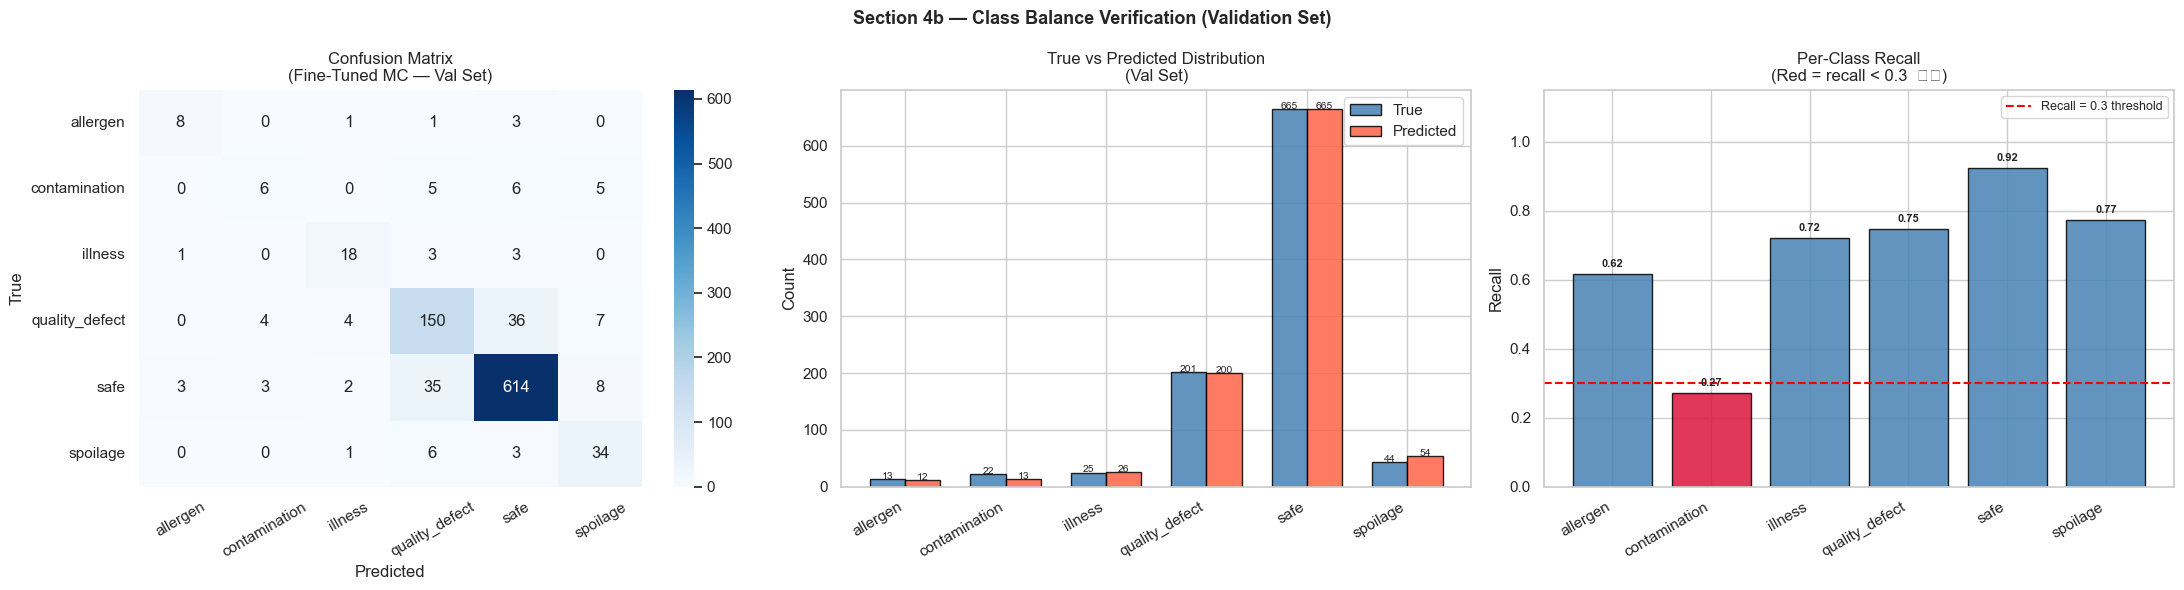


⚠️  WARNING — Classes with recall < 0.3:
   contamination        recall = 0.2727
   → Consider increasing MIN_SAMPLES target or adjusting class weights.

Class                 Precision     Recall    Support
────────────────────────────────────────────────────
allergen                 0.6667     0.6154         13
contamination            0.4615     0.2727         22
illness                  0.6923     0.7200         25
quality_defect           0.7500     0.7463        201
safe                     0.9233     0.9233        665
spoilage                 0.6296     0.7727         44


In [29]:
# ── Section 4b — Class Balance Verification ───────────────────────────
# Runs fine-tuned MC model on val set to verify class balance fix.

if not HAS_DEBERTA_MC:
    print('[SKIP] DeBERTa MC model not available. Run Section 4 training first.')
else:
    print('Loading fine-tuned MC model for class balance verification...')
    _mc_verify = hf_pipeline(
        'text-classification',
        model=CONFIG['deberta_mc_path'],
        tokenizer=CONFIG['deberta_mc_path'],
        device=DEVICE_ID, truncation=True, max_length=256,
        batch_size=CONFIG['ft_deberta_batch'],
    )

    # Reconstruct val set with same seed used during training
    _df_gold_v = pd.read_csv(CONFIG['gold_path'])
    _df_gold_v['label'] = _df_gold_v['label'].str.lower().str.strip()
    _df_tv_v, _ = train_test_split(
        _df_gold_v, test_size=0.10, stratify=_df_gold_v['label'], random_state=42
    )
    _, _df_val_v = train_test_split(
        _df_tv_v, test_size=1/9, stratify=_df_tv_v['label'], random_state=42
    )
    print(f'Val set: n={len(_df_val_v):,}  |  label distribution:')
    print(_df_val_v['label'].value_counts().to_string())

    # Run MC inference on val set
    _val_texts_v = _df_val_v['Text'].fillna('').tolist()
    _val_preds_v = []
    _BSZ_V = CONFIG['ft_deberta_batch']
    for _i in tqdm(range(0, len(_val_texts_v), _BSZ_V), desc='Verifying MC (val set)'):
        for _r in _mc_verify(_val_texts_v[_i:_i + _BSZ_V]):
            _val_preds_v.append(_r['label'].lower())

    _y_true_v = _df_val_v['label'].str.lower().values
    _y_pred_v = np.array(_val_preds_v)

    # ── Classification report per class ───────────────────────────────
    _present_v = sorted(set(list(_y_true_v)) | set(list(_y_pred_v)))
    print('\n' + '=' * 68)
    print('  CLASSIFICATION REPORT — Validation Set (Section 4b)')
    print('=' * 68)
    print(classification_report(_y_true_v, _y_pred_v, labels=_present_v, zero_division=0))

    # ── Plots ─────────────────────────────────────────────────────────
    _cm_v = confusion_matrix(_y_true_v, _y_pred_v, labels=_present_v)
    _true_vc_v = pd.Series(_y_true_v).value_counts().reindex(_present_v, fill_value=0)
    _pred_vc_v = pd.Series(_y_pred_v).value_counts().reindex(_present_v, fill_value=0)

    _recalls_v, _precisions_v = [], []
    for _lbl_v in _present_v:
        _y_t_bin = (_y_true_v == _lbl_v).astype(int)
        _y_p_bin = (_y_pred_v == _lbl_v).astype(int)
        _recalls_v.append(recall_score(_y_t_bin, _y_p_bin, zero_division=0))
        _precisions_v.append(precision_score(_y_t_bin, _y_p_bin, zero_division=0))

    fig_v, axes_v = plt.subplots(1, 3, figsize=(22, 6))
    fig_v.suptitle('Section 4b — Class Balance Verification (Validation Set)',
                   fontsize=13, fontweight='bold')

    # Panel 1: Confusion matrix
    sns.heatmap(_cm_v, annot=True, fmt='d', cmap='Blues', ax=axes_v[0],
                xticklabels=_present_v, yticklabels=_present_v)
    axes_v[0].set_title('Confusion Matrix\n(Fine-Tuned MC — Val Set)')
    axes_v[0].set_xlabel('Predicted')
    axes_v[0].set_ylabel('True')
    axes_v[0].tick_params(axis='x', rotation=30)
    axes_v[0].tick_params(axis='y', rotation=0)

    # Panel 2: True vs Predicted distribution
    _xv = np.arange(len(_present_v))
    _wv = 0.35
    axes_v[1].bar(_xv - _wv/2, _true_vc_v.values, _wv, label='True',
                  color='steelblue', edgecolor='black', alpha=0.85)
    axes_v[1].bar(_xv + _wv/2, _pred_vc_v.values, _wv, label='Predicted',
                  color='tomato', edgecolor='black', alpha=0.85)
    axes_v[1].set_xticks(_xv)
    axes_v[1].set_xticklabels(_present_v, rotation=30, ha='right')
    axes_v[1].set_title('True vs Predicted Distribution\n(Val Set)')
    axes_v[1].set_ylabel('Count')
    axes_v[1].legend()
    for _bar in axes_v[1].patches:
        _h = int(_bar.get_height())
        if _h > 0:
            axes_v[1].text(_bar.get_x() + _bar.get_width() / 2, _h + 0.3,
                           str(_h), ha='center', fontsize=7.5)

    # Panel 3: Per-class recall (red = recall < 0.3)
    _bar_colors_v = ['crimson' if r < 0.3 else 'steelblue' for r in _recalls_v]
    _bars_r = axes_v[2].bar(_present_v, _recalls_v, color=_bar_colors_v,
                             edgecolor='black', alpha=0.85)
    axes_v[2].axhline(0.3, color='red', linestyle='--', linewidth=1.5,
                      label='Recall = 0.3 threshold')
    axes_v[2].set_xticks(range(len(_present_v)))
    axes_v[2].set_xticklabels(_present_v, rotation=30, ha='right')
    axes_v[2].set_title('Per-Class Recall\n(Red = recall < 0.3  ⚠️)')
    axes_v[2].set_ylabel('Recall')
    axes_v[2].set_ylim(0, 1.15)
    axes_v[2].legend(fontsize=9)
    for _i_v, _r_v in enumerate(_recalls_v):
        axes_v[2].text(_i_v, _r_v + 0.02, f'{_r_v:.2f}',
                       ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── Automatic warnings ─────────────────────────────────────────────
    _low_recall = [(lbl, r) for lbl, r in zip(_present_v, _recalls_v) if r < 0.3]
    if _low_recall:
        print('\n⚠️  WARNING — Classes with recall < 0.3:')
        for _lbl_w, _r_w in _low_recall:
            print(f'   {_lbl_w:<20} recall = {_r_w:.4f}')
        print('   → Consider increasing MIN_SAMPLES target or adjusting class weights.')
    else:
        print('\n✓ All classes have recall >= 0.3. Class balance looks good!')

    # ── Summary table ─────────────────────────────────────────────────
    print(f'\n{"Class":<20} {"Precision":>10} {"Recall":>10} {"Support":>10}')
    print('─' * 52)
    for _lbl_s, _p_s, _r_s in zip(_present_v, _precisions_v, _recalls_v):
        _sup = int((_y_true_v == _lbl_s).sum())
        print(f'{_lbl_s:<20} {_p_s:>10.4f} {_r_s:>10.4f} {_sup:>10,}')


---
## Section 5 — Fine-Tuned Pipeline + Late Weighting

Replaces both zero-shot models with fine-tuned versions on the full dataset.  
Cache files are kept separate from zero-shot results and from v2 caches.

| Stage | Cache file |
|-------|------------|
| 5.1 MiniLM FT  | `cache_v3/stage1_ft_v3.pkl` |
| 5.2 DeBERTa FT (binary) | `cache_v3/stage2_ft_v3.pkl` |
| 5.3 DeBERTa MC (6-class) | `cache_v3/stage2_ft_mc.pkl` |


In [30]:
# ── 5.1  Stage 1 — Fine-Tuned MiniLM ──────────────────────────────────
CACHE_S1_FT = os.path.join(CONFIG['cache_dir'], 'stage1_ft_v3.pkl')

if not HAS_MINILM_FT:
    print('[SKIP] MiniLM FT model not found.')
elif os.path.exists(CACHE_S1_FT):
    print(f'Cache found: {CACHE_S1_FT}  — loading...')
    with open(CACHE_S1_FT, 'rb') as f:
        df_ft = pickle.load(f)
    print(f'Loaded {len(df_ft):,} rows from cache.')
else:
    print(f'Loading fine-tuned MiniLM from {CONFIG["minilm_ft_path"]}...')
    minilm_ft = SentenceTransformer(CONFIG['minilm_ft_path'], device=DEVICE)
    probe_emb_ft = minilm_ft.encode(SAFETY_PROBES, convert_to_tensor=True, show_progress_bar=False)
    print('Fine-tuned MiniLM ready.')

    COL.create_index([('SemanticScore_FT', 1)], sparse=True, background=True)
    THR = CONFIG['minilm_ft_threshold']
    BSZ = CONFIG['encode_batch_size']
    MCH = CONFIG['max_chars_encode']

    batch_texts, batch_keys = [], []
    with tqdm(total=len(unique_texts), desc='MiniLM FT encoding', unit='texts') as pbar:
        for txt in unique_texts:
            batch_texts.append(txt[:MCH]); batch_keys.append(txt)
            if len(batch_texts) == BSZ:
                emb    = minilm_ft.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
                scores = util.cos_sim(emb, probe_emb_ft).max(dim=1).values.cpu().numpy()
                ops    = [
                    UpdateOne({'_id': doc_id},
                              {'$set': {'SemanticScore_FT': float(s), 'SemanticFlagged_FT': float(s) >= THR}})
                    for key, s in zip(batch_keys, scores)
                    for doc_id in text_to_ids[key]
                ]
                COL.bulk_write(ops, ordered=False)
                batch_texts, batch_keys = [], []
                pbar.update(BSZ)
        if batch_texts:
            emb    = minilm_ft.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
            scores = util.cos_sim(emb, probe_emb_ft).max(dim=1).values.cpu().numpy()
            ops    = [
                UpdateOne({'_id': doc_id},
                          {'$set': {'SemanticScore_FT': float(s), 'SemanticFlagged_FT': float(s) >= THR}})
                for key, s in zip(batch_keys, scores)
                for doc_id in text_to_ids[key]
            ]
            COL.bulk_write(ops, ordered=False)
            pbar.update(len(batch_texts))

    cursor_ft = COL.find({'SemanticScore_FT': {'$exists': True}},
                          {'_id': 1, 'Score': 1, 'SemanticScore_FT': 1, 'SemanticFlagged_FT': 1})
    df_ft = pd.DataFrame(list(cursor_ft))
    with open(CACHE_S1_FT, 'wb') as f:
        pickle.dump(df_ft, f)
    print(f'Cache saved: {CACHE_S1_FT}')

if 'df_ft' in dir():
    df_ft['SemanticFlagged_FT'] = df_ft['SemanticFlagged_FT'].fillna(False).astype(bool)
    n_total_ft   = len(df_ft)
    n_flagged_ft = int(df_ft['SemanticFlagged_FT'].sum())
    print(f'Total reviews      : {n_total_ft:,}')
    print(f'MiniLM FT flagged  : {n_flagged_ft:,}  ({n_flagged_ft / n_total_ft:.2%})')


Loading fine-tuned MiniLM from models_v3/minilm_food_safety...
Fine-tuned MiniLM ready.


MiniLM FT encoding: 100%|██████████| 393579/393579 [05:09<00:00, 1271.08texts/s]


Cache saved: cache_v3\stage1_ft_v3.pkl
Total reviews      : 568,454
MiniLM FT flagged  : 150,850  (26.54%)


In [31]:
# ── 5.2  Stage 2 — Fine-Tuned DeBERTa (Binary) ────────────────────────
CACHE_S2_FT = os.path.join(CONFIG['cache_dir'], 'stage2_ft_v3.pkl')

if not HAS_DEBERTA_FT:
    print('[SKIP] DeBERTa FT model not found.')
elif os.path.exists(CACHE_S2_FT):
    print(f'Cache found: {CACHE_S2_FT}  — loading...')
    with open(CACHE_S2_FT, 'rb') as f:
        candidates_ft = pickle.load(f)
    print(f'Loaded {len(candidates_ft):,} candidates from cache.')
else:
    candidates_ft = df_ft[df_ft['SemanticFlagged_FT']].copy().reset_index(drop=True)
    cand_ids_ft   = candidates_ft['_id'].tolist()
    text_map_ft   = {d['_id']: d.get('Text', '')
                     for d in COL.find({'_id': {'$in': cand_ids_ft}}, {'Text': 1})}
    candidates_ft['Text'] = candidates_ft['_id'].map(text_map_ft).fillna('')
    print(f'Text loaded for {candidates_ft["Text"].ne("").sum():,} FT candidates.')

    print(f'Loading fine-tuned DeBERTa from {CONFIG["deberta_ft_path"]}...')
    ft_deberta = hf_pipeline('text-classification',
                              model=CONFIG['deberta_ft_path'],
                              tokenizer=CONFIG['deberta_ft_path'],
                              device=DEVICE_ID, truncation=True, max_length=256,
                              batch_size=CONFIG['ft_deberta_batch'])

    MCH = CONFIG['max_chars_deberta']
    BSZ = CONFIG['ft_deberta_batch']
    texts_full = candidates_ft['Text'].tolist()

    # ── Sentence splitting: expand each review into chunks ────────────
    all_chunks, chunk_to_rev = [], []
    for rev_idx, text in enumerate(texts_full):
        chunks = split_into_chunks(text, MCH)
        all_chunks.extend(chunks)
        chunk_to_rev.extend([rev_idx] * len(chunks))
    print(f'Reviews: {len(texts_full):,}  →  Chunks: {len(all_chunks):,}  '
          f'(avg {len(all_chunks)/max(len(texts_full),1):.1f} chunks/review)')

    # ── Run inference on all chunks ───────────────────────────────────
    chunk_labels_raw, chunk_confs_raw = [], []
    for i in tqdm(range(0, len(all_chunks), BSZ), desc='DeBERTa FT inference'):
        for res in ft_deberta(all_chunks[i:i+BSZ]):
            chunk_labels_raw.append(res['label'])
            chunk_confs_raw.append(res['score'])

    # ── Max-pool: keep max hazard probability per review ──────────────
    n_reviews           = len(texts_full)
    review_hazard_score = [0.0] * n_reviews
    for chunk_idx, (label, conf) in enumerate(zip(chunk_labels_raw, chunk_confs_raw)):
        rev_idx      = chunk_to_rev[chunk_idx]
        hazard_score = conf if label == 'hazard' else (1.0 - conf)
        if hazard_score > review_hazard_score[rev_idx]:
            review_hazard_score[rev_idx] = hazard_score

    ft_labels = ['hazard' if s >= 0.5 else 'safe' for s in review_hazard_score]
    ft_confs  = review_hazard_score

    candidates_ft['FTLabel']     = ft_labels
    candidates_ft['FTScore']     = ft_confs
    candidates_ft['FTConfirmed'] = candidates_ft['FTLabel'] == 'hazard'

    with open(CACHE_S2_FT, 'wb') as f:
        pickle.dump(candidates_ft, f)
    print(f'Cache saved: {CACHE_S2_FT}')

if 'candidates_ft' in dir():
    confirmed_ft_bin = candidates_ft[candidates_ft['FTConfirmed']].copy()
    n_confirmed_ft   = len(confirmed_ft_bin)
    print(f'Stage 1 FT flagged    : {n_flagged_ft:,}')
    print(f'Stage 2 FT confirmed  : {n_confirmed_ft:,}  ({n_confirmed_ft / n_total_ft:.4%} of total)')


Text loaded for 150,850 FT candidates.
Loading fine-tuned DeBERTa from models_v3/deberta_food_safety...


c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
The tokenizer you are loading from 'models_v3/deberta_food_safety' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Reviews: 150,850  →  Chunks: 460,325  (avg 3.1 chunks/review)


DeBERTa FT inference: 100%|██████████| 14386/14386 [3:29:19<00:00,  1.15it/s]  


Cache saved: cache_v3\stage2_ft_v3.pkl
Stage 1 FT flagged    : 150,850
Stage 2 FT confirmed  : 106,690  (18.7684% of total)


In [34]:
# ── 5.3  Stage 2b — Multi-class Category Assignment (optional) ─────────
CACHE_S2_MC = os.path.join(CONFIG['cache_dir'], 'stage2_ft_mc.pkl')

if not HAS_DEBERTA_MC:
    print('[SKIP] DeBERTa MC model not found. Category will be set to "unknown".')
    if 'confirmed_ft_bin' in dir():
        confirmed_ft_bin['pred_category']  = 'unknown'
        confirmed_ft_bin['pred_cat_score'] = 0.0
elif os.path.exists(CACHE_S2_MC):
    print(f'Cache found: {CACHE_S2_MC}  — loading...')
    with open(CACHE_S2_MC, 'rb') as f:
        mc_cache = pickle.load(f)
    confirmed_ft_bin['pred_category']  = mc_cache['pred_category']
    confirmed_ft_bin['pred_cat_score'] = mc_cache['pred_cat_score']
    print(f'MC categories loaded for {len(confirmed_ft_bin):,} confirmed hazards.')
else:
    print(f'Loading multi-class DeBERTa from {CONFIG["deberta_mc_path"]}...')
    mc_deberta = hf_pipeline('text-classification',
                              model=CONFIG['deberta_mc_path'],
                              tokenizer=CONFIG['deberta_mc_path'],
                              device=DEVICE_ID, truncation=True, max_length=256,
                              batch_size=CONFIG['ft_deberta_batch'],
                              torch_dtype=torch.float16)

    MCH = CONFIG['max_chars_deberta']
    BSZ = CONFIG['ft_deberta_batch']
    texts_full = confirmed_ft_bin['Text'].tolist()

    # ── Sentence splitting: expand each review into chunks ────────────
    all_chunks, chunk_to_rev = [], []
    for rev_idx, text in enumerate(texts_full):
        chunks = split_into_chunks(text, MCH)
        all_chunks.extend(chunks)
        chunk_to_rev.extend([rev_idx] * len(chunks))
    print(f'Reviews: {len(texts_full):,}  →  Chunks: {len(all_chunks):,}  '
          f'(avg {len(all_chunks)/max(len(texts_full),1):.1f} chunks/review)')

    # ── Run inference on all chunks ───────────────────────────────────
    chunk_mc_labels, chunk_mc_scores = [], []
    for i in tqdm(range(0, len(all_chunks), BSZ), desc='DeBERTa MC inference'):
        for r in mc_deberta(all_chunks[i:i+BSZ]):
            chunk_mc_labels.append(r['label'])
            chunk_mc_scores.append(r['score'])

    # ── Max-pool: keep chunk with highest hazard signal per review ────
    # hazard_conf = score if label != 'safe' else (1 - score)
    n_reviews          = len(texts_full)
    review_best_label  = ['safe'] * n_reviews
    review_best_score  = [0.0]   * n_reviews
    review_best_hazard = [0.0]   * n_reviews
    for chunk_idx, (label, score) in enumerate(zip(chunk_mc_labels, chunk_mc_scores)):
        rev_idx     = chunk_to_rev[chunk_idx]
        hazard_conf = score if label != 'safe' else (1.0 - score)
        if hazard_conf > review_best_hazard[rev_idx]:
            review_best_hazard[rev_idx] = hazard_conf
            review_best_label[rev_idx]  = label
            review_best_score[rev_idx]  = score

    mc_cats   = review_best_label
    mc_scores = review_best_score

    confirmed_ft_bin['pred_category']  = mc_cats
    confirmed_ft_bin['pred_cat_score'] = mc_scores
    with open(CACHE_S2_MC, 'wb') as f:
        pickle.dump({'pred_category': mc_cats, 'pred_cat_score': mc_scores}, f)
    print(f'MC cache saved: {CACHE_S2_MC}')

# ── Normalize pred_category to title case ────────────────────────────
# The MC model was trained with lowercase MC_LABEL_NAMES ('quality_defect', 'safe', ...).
# Remap to match ZS pipeline casing ('Quality_Defect', 'Safe', ...) so filters and
# visualisations are consistent across both pipelines.
if 'confirmed_ft_bin' in dir() and 'pred_category' in confirmed_ft_bin.columns:
    _mc_norm = {v: k for k, v in CATEGORY_TO_LABEL.items()}  # {'illness': 'Illness', ...}
    confirmed_ft_bin['pred_category'] = (
        confirmed_ft_bin['pred_category'].map(lambda x: _mc_norm.get(str(x).lower(), x))
    )

if 'confirmed_ft_bin' in dir() and 'pred_category' in confirmed_ft_bin.columns:
    print('\nCategory distribution (fine-tuned pipeline):')
    print(confirmed_ft_bin['pred_category'].value_counts().to_string())

# ── Apply late weighting (star-rating × Wilson credibility) ──────────
if 'confirmed_ft_bin' in dir():
    confirmed_ft_bin = confirmed_ft_bin.copy()
    confirmed_ft_bin['WilsonScore']      = confirmed_ft_bin['_id'].map(lambda oid: oid_wilson_map.get(oid, 0.5))
    confirmed_ft_bin['Weight']           = confirmed_ft_bin['Score'].apply(get_weight) * (0.5 + 0.5 * confirmed_ft_bin['WilsonScore'])
    confirmed_ft_bin['FinalSafetyScore'] = (confirmed_ft_bin['FTScore'] * confirmed_ft_bin['Weight']).round(4)
    print('\nFine-tuned FinalSafetyScore after late weighting:')
    print(confirmed_ft_bin['FinalSafetyScore'].describe().round(4).to_string())

    # Convenience alias used in later sections
    confirmed_ft = confirmed_ft_bin


Loading multi-class DeBERTa from models_v3/deberta_food_safety_mc...


The tokenizer you are loading from 'models_v3/deberta_food_safety_mc' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Reviews: 106,690  →  Chunks: 351,557  (avg 3.3 chunks/review)


DeBERTa MC inference: 100%|██████████| 10987/10987 [1:15:18<00:00,  2.43it/s]


MC cache saved: cache_v3\stage2_ft_mc.pkl

Category distribution (fine-tuned pipeline):
pred_category
Quality_Defect    64700
Spoilage          12795
Illness           10607
Safe               9023
Contamination      5720
Allergen           3845

Fine-tuned FinalSafetyScore after late weighting:
count    106690.0000
mean          0.3812
std           0.2424
min           0.0250
25%           0.0666
50%           0.4901
75%           0.5455
max           0.9873


---
## Section 6 — Evaluation vs Gold Dataset (Fine-Tuned)

Same held-out test split, same evaluation function — compare directly to Section 3.

In [35]:

if not HAS_DEBERTA_FT:
    print('[SKIP] Fine-tuned models not loaded. Run Section 4 first.')
else:
    # Build text → Amazon Id map via batched _id lookup (avoids 16MB BSON limit)
    print('Building text → Amazon Id map for fine-tuned confirmed reviews...')
    text_to_amazon_id_ft = build_text_to_amazon_id(confirmed_ft)
    print(f'Mapped {len(text_to_amazon_id_ft):,} unique texts to Amazon Ids.')

    # Use pred_category if MC ran, otherwise derive from FTLabel
    ft_label_col  = 'pred_category' if 'pred_category' in confirmed_ft.columns else 'FTLabel'
    ft_score_col  = 'pred_cat_score' if ft_label_col == 'pred_category' else 'FTScore'

    # Temporarily map 'hazard'/'safe' FTLabel to category space if no MC
    if ft_label_col == 'FTLabel':
        confirmed_ft = confirmed_ft.copy()
        confirmed_ft['_eval_cat'] = confirmed_ft['FTLabel'].map(
            lambda x: 'Illness' if x == 'hazard' else 'Safe'
        )
        ft_label_col = '_eval_cat'

    metrics_ft, df_merged_ft = evaluate_on_holdout(
        confirmed_ft, text_to_amazon_id_ft,
        label_col=ft_label_col, score_col=ft_score_col, tag='Fine-Tuned'
    )

    # Print side-by-side summary
    print('\n=== Zero-Shot vs Fine-Tuned — Quick Comparison ===')
    print(f'{"Metric":<12} {"Zero-Shot":>12} {"Fine-Tuned":>12} {"Delta":>8}')
    print('-' * 48)
    for key in ['Precision', 'Recall', 'F1']:
        zs = metrics_zs[key]; ft = metrics_ft[key]
        print(f'{key:<12} {zs:>12.4f} {ft:>12.4f} {ft-zs:>+8.4f}')


Building text → Amazon Id map for fine-tuned confirmed reviews...
Mapped 74,401 unique texts to Amazon Ids.
=== Evaluation: Fine-Tuned (held-out test set, n=970) ===
  Actual hazards  : 305
  Predicted       : 341
  TP=255  FP=86  FN=50  TN=579
  Precision=0.7478  Recall=0.8361  F1=0.7895
  FN rate (missed hazards): 16.39%

--- Multiclass Report ---
                precision    recall  f1-score   support

quality_defect       0.70      0.76      0.73       201
       illness       0.53      0.68      0.60        25
      spoilage       0.72      0.77      0.75        44
 contamination       0.57      0.55      0.56        22
      allergen       0.33      0.54      0.41        13
          safe       0.92      0.87      0.89       665

      accuracy                           0.83       970
     macro avg       0.63      0.69      0.66       970
  weighted avg       0.84      0.83      0.83       970


=== Zero-Shot vs Fine-Tuned — Quick Comparison ===
Metric          Zero-Shot   Fine-

---
## Section 6b — Benchmark: DeBERTa-Only vs MiniLM + DeBERTa

Goal: **prove** that the two-stage pipeline (MiniLM pre-filter → DeBERTa only on candidates)
is significantly faster than running DeBERTa directly on **all** reviews.

| Approach | How it works | Drawback |
|---|---|---|
| **DeBERTa-Only** | DeBERTa reads every review → hazard/safe | Very slow on 500k+ reviews |
| **MiniLM + DeBERTa** | MiniLM filters ~5–15% candidates → DeBERTa only on those | Slight recall drop if MiniLM misses a hazard |

Benchmark is run on the **held-out test set (n=500)** and inference time is extrapolated to the full dataset.
Results are cached in `cache/benchmark_speed.pkl`.


In [36]:
import time

CACHE_BENCH = os.path.join(CONFIG['cache_dir'], 'benchmark_speed.pkl')

df_bench_test = pd.read_csv(CONFIG['test_holdout_path'])
bench_texts   = df_bench_test['Text'].fillna('').tolist()
y_true_bench  = df_bench_test['human_is_hazard'].astype(int).values
n_bench       = len(df_bench_test)
N_FULL        = total_docs
MCH           = CONFIG['max_chars_deberta']
BSZ           = CONFIG['ft_deberta_batch']
THR_ML        = CONFIG['minilm_ft_threshold']

# Load models into memory if pipeline ran from cache (not re-created in this session)
if 'ft_deberta' not in dir():
    print('Loading FT DeBERTa for benchmark...')
    ft_deberta = hf_pipeline('text-classification',
                              model=CONFIG['deberta_ft_path'],
                              tokenizer=CONFIG['deberta_ft_path'],
                              device=DEVICE_ID, truncation=True, max_length=256,
                              batch_size=BSZ)
if 'minilm_ft' not in dir():
    print('Loading FT MiniLM for benchmark...')
    minilm_ft = SentenceTransformer(CONFIG['minilm_ft_path'], device=DEVICE)

_probe_bench = minilm_ft.encode(SAFETY_PROBES, convert_to_tensor=True, show_progress_bar=False)
print(f'Benchmark on {n_bench:,} test reviews  |  full dataset: {N_FULL:,} reviews')
print(f'DeBERTa chunk size: {MCH} chars  |  MiniLM threshold: {THR_ML}\n')

if os.path.exists(CACHE_BENCH):
    print(f'Cache found: {CACHE_BENCH}  — loading...')
    with open(CACHE_BENCH, 'rb') as f:
        _bd = pickle.load(f)
    t_a      = _bd['t_a'];     y_pred_bench_a = _bd['y_pred_a']
    t_b      = _bd['t_b'];     y_pred_bench_b = _bd['y_pred_b']
    nc_a     = _bd['nc_a'];    nc_b           = _bd['nc_b']
    n_flag_b = _bd['n_flag_b']
    print('Loaded.')
else:
    # ── Approach A: DeBERTa-Only (no MiniLM pre-filter) ──────────────
    print('Running Approach A: DeBERTa-Only...')
    _t0 = time.perf_counter()
    _cks_a, _cr_a = [], []
    for _ri, _tx in enumerate(bench_texts):
        _c = split_into_chunks(_tx, MCH)
        _cks_a.extend(_c)
        _cr_a.extend([_ri] * len(_c))

    _ll_a, _lc_a = [], []
    for _i in tqdm(range(0, len(_cks_a), BSZ), desc='DeBERTa-Only'):
        for _r in ft_deberta(_cks_a[_i:_i + BSZ]):
            _ll_a.append(_r['label'])
            _lc_a.append(_r['score'])

    _hs_a = [0.0] * n_bench
    for _ci, (_l, _c) in enumerate(zip(_ll_a, _lc_a)):
        _ri = _cr_a[_ci]
        _h  = _c if _l == 'hazard' else (1.0 - _c)
        if _h > _hs_a[_ri]:
            _hs_a[_ri] = _h

    y_pred_bench_a = [1 if s >= 0.5 else 0 for s in _hs_a]
    nc_a = len(_cks_a)
    t_a  = time.perf_counter() - _t0
    print(f'  Done: {t_a:.2f}s  |  {nc_a:,} chunks')

    # ── Approach B: MiniLM FT → DeBERTa FT (two-stage) ───────────────
    print('Running Approach B: MiniLM FT + DeBERTa FT...')
    _t0 = time.perf_counter()

    _embs  = minilm_ft.encode(bench_texts, batch_size=BSZ,
                               convert_to_tensor=True, show_progress_bar=False)
    _mls   = util.cos_sim(_embs, _probe_bench).max(dim=1).values.cpu().numpy()
    _fi    = [i for i, s in enumerate(_mls) if s >= THR_ML]
    _ftxt  = [bench_texts[i] for i in _fi]
    n_flag_b = len(_fi)

    _cks_b, _cl_b = [], []
    for _li, _tx in enumerate(_ftxt):
        _c = split_into_chunks(_tx, MCH)
        _cks_b.extend(_c)
        _cl_b.extend([_li] * len(_c))

    _ll_b, _lc_b = [], []
    for _i in tqdm(range(0, len(_cks_b), BSZ), desc='DeBERTa on flagged'):
        for _r in ft_deberta(_cks_b[_i:_i + BSZ]):
            _ll_b.append(_r['label'])
            _lc_b.append(_r['score'])

    _hs_b = [0.0] * n_flag_b
    for _ci, (_l, _c) in enumerate(zip(_ll_b, _lc_b)):
        _li = _cl_b[_ci]
        _h  = _c if _l == 'hazard' else (1.0 - _c)
        if _h > _hs_b[_li]:
            _hs_b[_li] = _h

    y_pred_bench_b = [0] * n_bench
    for _li, _ri in enumerate(_fi):
        y_pred_bench_b[_ri] = 1 if _hs_b[_li] >= 0.5 else 0
    nc_b = len(_cks_b)
    t_b  = time.perf_counter() - _t0
    print(f'  Done: {t_b:.2f}s  |  {n_flag_b:,}/{n_bench} to DeBERTa  |  {nc_b:,} chunks')

    with open(CACHE_BENCH, 'wb') as f:
        pickle.dump({'t_a': t_a, 'y_pred_a': y_pred_bench_a, 'nc_a': nc_a,
                     't_b': t_b, 'y_pred_b': y_pred_bench_b, 'nc_b': nc_b,
                     'n_flag_b': n_flag_b}, f)
    print(f'Cache saved: {CACHE_BENCH}')

# ── Compute metrics & extrapolate ────────────────────────────────────
m_bench_a     = binary_metrics(y_true_bench, y_pred_bench_a)
m_bench_b     = binary_metrics(y_true_bench, y_pred_bench_b)
speedup_bench = t_a / max(t_b, 1e-9)
t_a_full_h    = (t_a / n_bench * N_FULL) / 3600
t_b_full_h    = (t_b / n_bench * N_FULL) / 3600

_s1  = '─' * 36
_s2  = '─' * 15
_fl  = f'Est. time on full {N_FULL // 1000}k dataset'
_sp  = f'{speedup_bench:.1f}x faster'
_tpa = f'{m_bench_a["TP"]}/{m_bench_a["FP"]}/{m_bench_a["FN"]}/{m_bench_a["TN"]}'
_tpb = f'{m_bench_b["TP"]}/{m_bench_b["FP"]}/{m_bench_b["FN"]}/{m_bench_b["TN"]}'

print('\n' + '=' * 68)
print(f'  BENCHMARK RESULTS  (test n={n_bench}, full dataset={N_FULL:,})')
print('=' * 68)
print(f'{"Metric":<36} {"DeBERTa-Only":>15} {"MiniLM+DeBERTa":>15}')
print(f'{_s1} {_s2} {_s2}')
print(f'{"DeBERTa input chunks":<36} {nc_a:>15,} {nc_b:>15,}')
print(f'{"MiniLM flagged → DeBERTa":<36} {"all " + str(n_bench):>15} {str(n_flag_b) + "/" + str(n_bench):>15}')
print(f'{"Inference time (test set)":<36} {t_a:>14.2f}s {t_b:>14.2f}s')
print(f'{"Speedup":<36} {"1.0x":>15} {_sp:>15}')
print(f'{_s1} {_s2} {_s2}')
print(f'{"Precision":<36} {m_bench_a["Precision"]:>15.4f} {m_bench_b["Precision"]:>15.4f}')
print(f'{"Recall":<36} {m_bench_a["Recall"]:>15.4f} {m_bench_b["Recall"]:>15.4f}')
print(f'{"F1":<36} {m_bench_a["F1"]:>15.4f} {m_bench_b["F1"]:>15.4f}')
print(f'{"TP / FP / FN / TN":<36} {_tpa:>15} {_tpb:>15}')
print(f'{_s1} {_s2} {_s2}')
print(f'{_fl:<36} {t_a_full_h:>14.1f}h {t_b_full_h:>14.1f}h')
print('=' * 68)

_recall_diff = m_bench_b["Recall"] - m_bench_a["Recall"]
print(f'\n→ MiniLM+DeBERTa is {speedup_bench:.1f}x faster on {n_bench} reviews.')
print(f'→ Recall difference: {_recall_diff:+.4f}  '
      f'({"negligible" if abs(_recall_diff) < 0.03 else "tradeoff"})')
print(f'→ Full dataset: DeBERTa-only ≈ {t_a_full_h:.1f}h  vs  MiniLM+DeBERTa ≈ {t_b_full_h:.1f}h')
print(f'   Running DeBERTa directly on {N_FULL:,} reviews is {"impractical" if t_a_full_h > 1 else "feasible"}.')


Benchmark on 970 test reviews  |  full dataset: 568,454 reviews
DeBERTa chunk size: 256 chars  |  MiniLM threshold: 0.27

Running Approach A: DeBERTa-Only...


DeBERTa-Only: 100%|██████████| 79/79 [00:35<00:00,  2.24it/s]


  Done: 35.26s  |  2,525 chunks
Running Approach B: MiniLM FT + DeBERTa FT...


DeBERTa on flagged: 100%|██████████| 46/46 [00:23<00:00,  1.98it/s]

  Done: 28.82s  |  476/970 to DeBERTa  |  1,449 chunks
Cache saved: cache_v3\benchmark_speed.pkl

  BENCHMARK RESULTS  (test n=970, full dataset=568,454)
Metric                                  DeBERTa-Only  MiniLM+DeBERTa
──────────────────────────────────── ─────────────── ───────────────
DeBERTa input chunks                           2,525           1,449
MiniLM flagged → DeBERTa                     all 970         476/970
Inference time (test set)                     35.26s          28.82s
Speedup                                         1.0x     1.2x faster
──────────────────────────────────── ─────────────── ───────────────
Precision                                     0.6327          0.6872
Recall                                        0.9148          0.8787
F1                                            0.7480          0.7712
TP / FP / FN / TN                     279/162/26/503  268/122/37/543
──────────────────────────────────── ─────────────── ───────────────
Est. time on full 

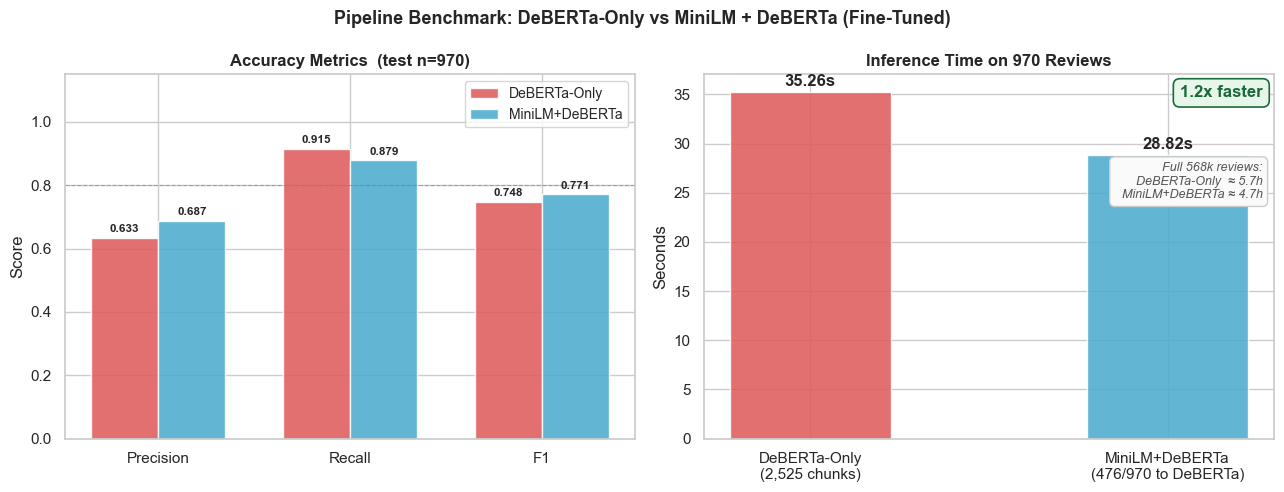

In [37]:
# ── Visualization: Accuracy & Speed Comparison ───────────────────────
fig_b, (ax_b1, ax_b2) = plt.subplots(1, 2, figsize=(13, 5))

COLOR_A = '#e05c5c'   # red  = DeBERTa-Only
COLOR_B = '#4dabce'   # blue = MiniLM+DeBERTa

# --- Left: Accuracy metrics ---
_keys_b = ['Precision', 'Recall', 'F1']
_va_b   = [m_bench_a[k] for k in _keys_b]
_vb_b   = [m_bench_b[k] for k in _keys_b]
_xb     = np.arange(len(_keys_b))
_wb     = 0.35

_ba_b = ax_b1.bar(_xb - _wb/2, _va_b, _wb, label='DeBERTa-Only',   color=COLOR_A, alpha=0.88)
_bb_b = ax_b1.bar(_xb + _wb/2, _vb_b, _wb, label='MiniLM+DeBERTa', color=COLOR_B, alpha=0.88)
for _b in list(_ba_b) + list(_bb_b):
    ax_b1.text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 0.012,
               f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax_b1.set_xticks(_xb)
ax_b1.set_xticklabels(_keys_b, fontsize=11)
ax_b1.set_ylim(0, 1.15)
ax_b1.set_title(f'Accuracy Metrics  (test n={n_bench})', fontweight='bold', fontsize=12)
ax_b1.set_ylabel('Score')
ax_b1.legend(fontsize=10)
ax_b1.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# --- Right: Inference time + extrapolation ---
_pipe_labels = [
    f'DeBERTa-Only\n({nc_a:,} chunks)',
    f'MiniLM+DeBERTa\n({n_flag_b}/{n_bench} to DeBERTa)',
]
_times  = [t_a, t_b]
_colors = [COLOR_A, COLOR_B]
_bt_b   = ax_b2.bar(_pipe_labels, _times, color=_colors, alpha=0.88, width=0.45)

for _b in _bt_b:
    ax_b2.text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 0.3,
               f'{_b.get_height():.2f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Speedup label
ax_b2.text(0.98, 0.97, f'{speedup_bench:.1f}x faster',
           transform=ax_b2.transAxes, ha='right', va='top',
           fontsize=12, color='#1a6b3c', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', edgecolor='#1a6b3c', linewidth=1.2))

# Extrapolation annotation
ax_b2.text(0.98, 0.76,
           f'Full {N_FULL//1000}k reviews:\n  DeBERTa-Only  ≈ {t_a_full_h:.1f}h\n  MiniLM+DeBERTa ≈ {t_b_full_h:.1f}h',
           transform=ax_b2.transAxes, ha='right', va='top',
           fontsize=9, color='#555', style='italic',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='#fafafa', edgecolor='#ccc', linewidth=1))

ax_b2.set_title(f'Inference Time on {n_bench} Reviews', fontweight='bold', fontsize=12)
ax_b2.set_ylabel('Seconds')

fig_b.suptitle('Pipeline Benchmark: DeBERTa-Only vs MiniLM + DeBERTa (Fine-Tuned)',
               fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 7 — Export to Excel

Exports **one combined workbook** with both pipeline results.

| Sheet | Contents |
|-------|----------|
| `ZS_Flagged`       | Zero-shot MiniLM flagged reviews |
| `ZS_Confirmed`     | Zero-shot DeBERTa confirmed with scores |
| `FT_Flagged`       | Fine-tuned MiniLM flagged reviews |
| `FT_Confirmed`     | Fine-tuned DeBERTa confirmed with scores & categories |

In [38]:
MAX_LEN  = CONFIG['excel_max_len']
OUT_FILE = os.path.join(CONFIG['output_dir'], 'food_safety_results_combined.xlsx')

with pd.ExcelWriter(OUT_FILE, engine='openpyxl') as writer:

    # ZS Flagged
    s_zs_flag = candidates_zs[['Score', 'SemanticScore', 'Category', 'Text']].copy()
    s_zs_flag['Text'] = clean_for_excel(s_zs_flag['Text'].str[:MAX_LEN])
    s_zs_flag.to_excel(writer, sheet_name='ZS_Flagged', index=False)

    # ZS Confirmed
    zs_cols = ['Score', 'WilsonScore', 'SemanticScore', 'DebertaScore', 'Category',
               'Severity', 'Weight', 'FinalSafetyScore', 'Text']
    s_zs_conf = confirmed_zs.sort_values('FinalSafetyScore', ascending=False)[
        [c for c in zs_cols if c in confirmed_zs.columns]
    ].copy()
    s_zs_conf['Text'] = clean_for_excel(s_zs_conf['Text'].str[:MAX_LEN])
    s_zs_conf.to_excel(writer, sheet_name='ZS_Confirmed', index=False)

    if 'confirmed_ft' in dir():
        # FT Flagged
        flagged_ft_all = df_ft[df_ft['SemanticFlagged_FT']].copy()
        text_lkp = candidates_ft.set_index('_id')['Text'].to_dict()
        flagged_ft_all['Text'] = flagged_ft_all['_id'].map(text_lkp).fillna('')
        s_ft_flag = flagged_ft_all[['Score', 'SemanticScore_FT', 'Text']].copy()
        s_ft_flag['Text'] = clean_for_excel(s_ft_flag['Text'].str[:MAX_LEN])
        s_ft_flag.to_excel(writer, sheet_name='FT_Flagged', index=False)

        # FT Confirmed
        ft_cols = ['Score', 'WilsonScore', 'SemanticScore_FT', 'FTLabel', 'FTScore',
                   'pred_category', 'pred_cat_score', 'Weight', 'FinalSafetyScore', 'Text']
        s_ft_conf = confirmed_ft.sort_values('FinalSafetyScore', ascending=False)[
            [c for c in ft_cols if c in confirmed_ft.columns]
        ].copy()
        s_ft_conf['Text'] = clean_for_excel(s_ft_conf['Text'].str[:MAX_LEN])
        s_ft_conf.to_excel(writer, sheet_name='FT_Confirmed', index=False)

print(f'Exported → {os.path.abspath(OUT_FILE)}')
print(f'  ZS_Flagged   : {len(s_zs_flag):,} rows')
print(f'  ZS_Confirmed : {len(s_zs_conf):,} rows')
if 'confirmed_ft' in dir():
    print(f'  FT_Flagged   : {len(s_ft_flag):,} rows')
    print(f'  FT_Confirmed : {len(s_ft_conf):,} rows')

Exported → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs_v3\food_safety_results_combined.xlsx
  ZS_Flagged   : 23,587 rows
  ZS_Confirmed : 10,096 rows
  FT_Flagged   : 150,850 rows
  FT_Confirmed : 106,690 rows


---
## Section 8 — Product-Level Assessment (Bayesian)

Groups confirmed hazard reviews by `ProductId` and computes a **Bayesian-smoothed** hazard score.

$$\text{BayesianScore} = \frac{v \cdot R + m \cdot C}{v + m}$$

- $v$ = total reviews for this product; $R$ = raw hazard score
- $m$ = Q95 of review-count distribution (prior strength); $C$ = global mean hazard score

Products are run for **both pipelines** and exported to a single workbook.

In [39]:

# ── Resolve ProductId for both pipelines ─────────────────────────────
def assign_product_ids(df_confirmed, batch_size=2000):
    """
    Add ProductId column to a confirmed-hazards DataFrame.
    Uses batched _id lookup instead of $in with text strings to avoid
    the 16MB BSON document size limit.
    """
    text_to_prods = defaultdict(list)
    ids = df_confirmed['_id'].tolist()
    for i in range(0, len(ids), batch_size):
        batch = ids[i:i + batch_size]
        for d in COL.find({'_id': {'$in': batch}}, {'Text': 1, 'ProductId': 1}):
            prod = d.get('ProductId', 'UNKNOWN')
            key  = str(d.get('Text', ''))
            if prod not in text_to_prods[key]:
                text_to_prods[key].append(prod)

    counters = defaultdict(int)
    def _pick(text):
        key   = str(text) if pd.notna(text) else ''
        prods = text_to_prods.get(key, ['UNKNOWN'])
        idx   = counters[key] % len(prods)
        counters[key] += 1
        return prods[idx]

    df_confirmed = df_confirmed.copy()
    df_confirmed['ProductId'] = df_confirmed['Text'].apply(_pick)
    return df_confirmed

confirmed_zs = assign_product_ids(confirmed_zs)
if 'confirmed_ft' in dir():
    confirmed_ft = assign_product_ids(confirmed_ft)

# Total reviews per product (needed for Bayesian denominator)
total_per_product = {
    d['_id']: d['n']
    for d in COL.aggregate([{'$group': {'_id': '$ProductId', 'n': {'$sum': 1}}}])
}
print(f'Total products in dataset: {len(total_per_product):,}')


Total products in dataset: 74,258


In [40]:
# ── Build product summaries ───────────────────────────────────────────
prod_zs = build_product_summary(confirmed_zs, total_per_product)
prod_ft = build_product_summary(confirmed_ft, total_per_product) if 'confirmed_ft' in dir() else pd.DataFrame()

EXPORT_COLS = ['ProductId', 'TotalReviews', 'HazardCount', 'HazardRate',
               'BayesianScore', 'DominantCategory', 'RiskLevel']

PROD_FILE = os.path.join(CONFIG['output_dir'], 'product_safety_summary_combined.xlsx')
with pd.ExcelWriter(PROD_FILE, engine='openpyxl') as writer:
    prod_zs.sort_values('BayesianScore', ascending=False)[EXPORT_COLS].to_excel(
        writer, sheet_name='ZS_Unsafe_Products', index=False)
    if not prod_ft.empty:
        prod_ft.sort_values('BayesianScore', ascending=False)[EXPORT_COLS].to_excel(
            writer, sheet_name='FT_Unsafe_Products', index=False)

print(f'Exported → {os.path.abspath(PROD_FILE)}')

# ── Zero-Shot summary ─────────────────────────────────────────────────
print(f'\n[Zero-Shot] Unsafe products  : {len(prod_zs):,}')
if not prod_zs.empty:
    print('\n  Risk Level breakdown:')
    for lvl, cnt in prod_zs['RiskLevel'].value_counts().items():
        print(f'    {lvl:<14} {cnt:>6,}')
    print('\n  Dominant Category breakdown:')
    for cat, cnt in prod_zs['DominantCategory'].value_counts().items():
        pct = cnt / len(prod_zs) * 100
        print(f'    {cat:<20} {cnt:>6,}  ({pct:.1f}%)')

# ── Fine-Tuned summary ────────────────────────────────────────────────
if not prod_ft.empty:
    print(f'\n[Fine-Tuned] Unsafe products : {len(prod_ft):,}')
    print('\n  Risk Level breakdown:')
    for lvl, cnt in prod_ft['RiskLevel'].value_counts().items():
        print(f'    {lvl:<14} {cnt:>6,}')
    print('\n  Dominant Category breakdown:')
    for cat, cnt in prod_ft['DominantCategory'].value_counts().items():
        pct = cnt / len(prod_ft) * 100
        print(f'    {cat:<20} {cnt:>6,}  ({pct:.1f}%)')


Exported → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs_v3\product_safety_summary_combined.xlsx

[Zero-Shot] Unsafe products  : 5,945

  Risk Level breakdown:
    Low Risk        5,922
    Medium Risk        20
    High Risk           3

  Dominant Category breakdown:
    Contamination         3,736  (62.8%)
    Spoilage                997  (16.8%)
    Illness                 688  (11.6%)
    Quality_Defect          377  (6.3%)
    Allergen                147  (2.5%)

[Fine-Tuned] Unsafe products : 29,260

  Risk Level breakdown:
    Medium Risk    16,538
    High Risk      12,280
    Low Risk          442

  Dominant Category breakdown:
    Quality_Defect       21,292  (72.8%)
    Spoilage              3,316  (11.3%)
    Illness               2,420  (8.3%)
    Contamination         1,226  (4.2%)
    Allergen              1,006  (3.4%)


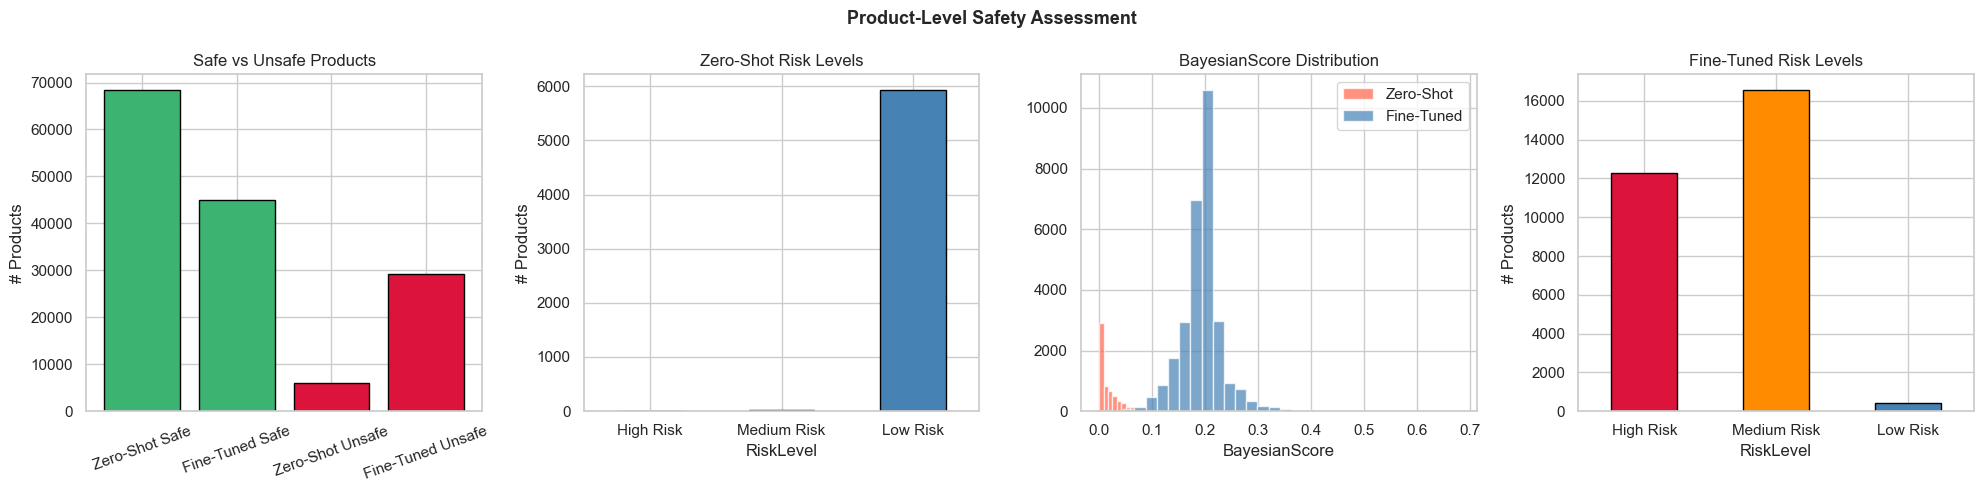

In [41]:
# ── Product-level visualisation ───────────────────────────────────────
n_total_prods  = len(total_per_product)
has_ft_prods   = not prod_ft.empty
ncols          = 4 if has_ft_prods else 3
fig, axes      = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
fig.suptitle('Product-Level Safety Assessment', fontsize=13, fontweight='bold')

# Panel 1: Safe vs Unsafe counts per pipeline
pipelines = ['Zero-Shot']
n_unsafe  = [len(prod_zs)]
if has_ft_prods:
    pipelines.append('Fine-Tuned'); n_unsafe.append(len(prod_ft))
n_safe    = [n_total_prods - u for u in n_unsafe]
x = range(len(pipelines))
axes[0].bar([p + ' Safe' for p in pipelines], n_safe,   color='mediumseagreen', edgecolor='black', label='Safe')
axes[0].bar([p + ' Unsafe' for p in pipelines], n_unsafe, color='crimson',        edgecolor='black', label='Unsafe')
axes[0].set_title('Safe vs Unsafe Products')
axes[0].set_ylabel('# Products')
axes[0].tick_params(axis='x', rotation=20)

# Panel 2: Risk breakdown ZS
risk_order  = ['High Risk', 'Medium Risk', 'Low Risk']
risk_zs     = prod_zs['RiskLevel'].value_counts().reindex(risk_order, fill_value=0)
risk_zs.plot(kind='bar', ax=axes[1], color=['crimson', 'darkorange', 'steelblue'],
             edgecolor='black', rot=0)
axes[1].set_title('Zero-Shot Risk Levels')
axes[1].set_ylabel('# Products')

# Panel 3: BayesianScore distribution ZS
axes[2].hist(prod_zs['BayesianScore'], bins=30, color='tomato', alpha=0.7, label='Zero-Shot')
if has_ft_prods:
    axes[2].hist(prod_ft['BayesianScore'], bins=30, color='steelblue', alpha=0.7, label='Fine-Tuned')
axes[2].set_title('BayesianScore Distribution')
axes[2].set_xlabel('BayesianScore')
axes[2].legend()

# Panel 4: Risk breakdown FT (if available)
if has_ft_prods:
    risk_ft = prod_ft['RiskLevel'].value_counts().reindex(risk_order, fill_value=0)
    risk_ft.plot(kind='bar', ax=axes[3], color=['crimson', 'darkorange', 'steelblue'],
                 edgecolor='black', rot=0)
    axes[3].set_title('Fine-Tuned Risk Levels')
    axes[3].set_ylabel('# Products')

plt.tight_layout()
plt.show()

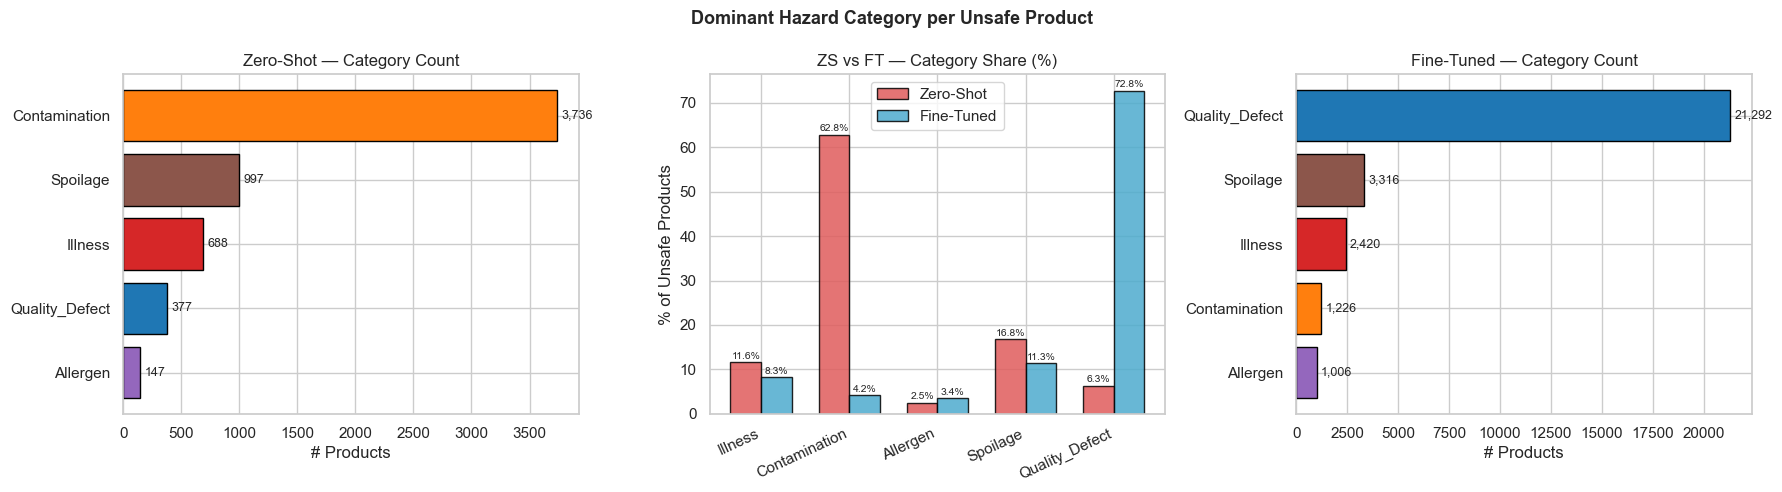

In [42]:
# ── Dominant Category comparison (ZS vs FT) ──────────────────────────
_ALL_CATS = ['Illness', 'Contamination', 'Allergen', 'Spoilage', 'Quality_Defect', 'unknown']
_CAT_COLORS = {
    'Illness':        '#d62728',
    'Contamination':  '#ff7f0e',
    'Allergen':       '#9467bd',
    'Spoilage':       '#8c564b',
    'Quality_Defect': '#1f77b4',
    'unknown':        '#7f7f7f',
}

# Gather present categories from both pipelines
_cats_zs = prod_zs['DominantCategory'].value_counts() if not prod_zs.empty else pd.Series(dtype=int)
_cats_ft = prod_ft['DominantCategory'].value_counts() if not prod_ft.empty else pd.Series(dtype=int)
_all_present = sorted(set(_cats_zs.index) | set(_cats_ft.index),
                      key=lambda c: _ALL_CATS.index(c) if c in _ALL_CATS else 99)

ncols_cat = 3 if not prod_ft.empty else 2
fig_cat, axes_cat = plt.subplots(1, ncols_cat, figsize=(6 * ncols_cat, 5))
fig_cat.suptitle('Dominant Hazard Category per Unsafe Product', fontsize=13, fontweight='bold')

# ── Panel 1: ZS absolute counts ──────────────────────────────────────
_colors_zs = [_CAT_COLORS.get(c, '#aec7e8') for c in _cats_zs.index]
axes_cat[0].barh(_cats_zs.index[::-1], _cats_zs.values[::-1], color=_colors_zs[::-1], edgecolor='black')
for i, (cat, val) in enumerate(zip(_cats_zs.index[::-1], _cats_zs.values[::-1])):
    axes_cat[0].text(val + max(_cats_zs.values) * 0.01, i, f'{val:,}', va='center', fontsize=9)
axes_cat[0].set_title('Zero-Shot — Category Count')
axes_cat[0].set_xlabel('# Products')

# ── Panel 2: ZS vs FT % side-by-side bar ─────────────────────────────
_width = 0.35
_x = range(len(_all_present))
_zs_pct = [_cats_zs.get(c, 0) / max(len(prod_zs), 1) * 100 for c in _all_present]
_ft_pct = [_cats_ft.get(c, 0) / max(len(prod_ft), 1) * 100 for c in _all_present]

bars_zs_c = axes_cat[1].bar([i - _width/2 for i in _x], _zs_pct, _width,
                              label='Zero-Shot',  color=COLOR_A, alpha=0.85, edgecolor='black')
bars_ft_c = axes_cat[1].bar([i + _width/2 for i in _x], _ft_pct, _width,
                              label='Fine-Tuned', color=COLOR_B, alpha=0.85, edgecolor='black')
axes_cat[1].set_xticks(list(_x))
axes_cat[1].set_xticklabels(_all_present, rotation=25, ha='right')
axes_cat[1].set_title('ZS vs FT — Category Share (%)')
axes_cat[1].set_ylabel('% of Unsafe Products')
axes_cat[1].legend()
for bar in list(bars_zs_c) + list(bars_ft_c):
    h = bar.get_height()
    if h > 0:
        axes_cat[1].text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                         f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5)

# ── Panel 3: FT absolute counts (if available) ───────────────────────
if not prod_ft.empty:
    _colors_ft = [_CAT_COLORS.get(c, '#aec7e8') for c in _cats_ft.index]
    axes_cat[2].barh(_cats_ft.index[::-1], _cats_ft.values[::-1], color=_colors_ft[::-1], edgecolor='black')
    for i, (cat, val) in enumerate(zip(_cats_ft.index[::-1], _cats_ft.values[::-1])):
        axes_cat[2].text(val + max(_cats_ft.values) * 0.01, i, f'{val:,}', va='center', fontsize=9)
    axes_cat[2].set_title('Fine-Tuned — Category Count')
    axes_cat[2].set_xlabel('# Products')

plt.tight_layout()
plt.show()


---
## Section 9 — Final Comparison

Side-by-side comparison across all dimensions:

| Panel | What it shows |
|-------|---------------|
| 9.1 Gold accuracy table | Precision / Recall / F1 — zero-shot vs fine-tuned |
| 9.2 Confusion matrices  | Heatmaps side-by-side |
| 9.3 Pipeline funnel     | Flagged → Confirmed counts |
| 9.4 Score distributions | FinalSafetyScore histograms overlaid |
| 9.5 Per-category        | Category breakdown: MiniLM vs DeBERTa stage contribution |

In [43]:
# ── 9.1  Gold accuracy comparison table ──────────────────────────────
print('=== Gold Accuracy — Held-Out Test Set ===')
print(f'{"Metric":<12} {"Zero-Shot":>12} {"Fine-Tuned":>12} {"Delta":>8}')
print('─' * 48)

for key in ['Precision', 'Recall', 'F1', 'FN_rate', 'TP', 'FP', 'FN', 'TN']:
    zs  = metrics_zs.get(key, 'N/A')
    ft  = metrics_ft.get(key, 'N/A') if 'metrics_ft' in dir() else 'N/A'
    if isinstance(zs, float) and isinstance(ft, float):
        print(f'{key:<12} {zs:>12.4f} {ft:>12.4f} {ft-zs:>+8.4f}')
    else:
        print(f'{key:<12} {str(zs):>12} {str(ft):>12}')

# Full dataset funnel
_ft_confirmed = confirmed_ft if 'confirmed_ft' in dir() else None
_avg_ft = f'{_ft_confirmed["FinalSafetyScore"].mean():>12.4f}' if _ft_confirmed is not None else f'{"N/A":>12}'

print('\n=== Full Dataset Funnel (~500k reviews) ===')
print(f'{"Stage":<35} {"Zero-Shot":>12} {"Fine-Tuned":>12}')
print('─' * 60)
print(f'{"Stage 1 threshold":<35} {CONFIG["semantic_threshold"]:>12.2f} {CONFIG["minilm_ft_threshold"]:>12.2f}')
print(f'{"Stage 1 flagged":<35} {n_flagged_zs:>12,} {n_flagged_ft if "n_flagged_ft" in dir() else "N/A":>12}')
print(f'{"Stage 2 confirmed":<35} {n_confirmed_zs:>12,} {n_confirmed_ft if "n_confirmed_ft" in dir() else "N/A":>12}')
print(f'{"Avg FinalSafetyScore":<35} {confirmed_zs["FinalSafetyScore"].mean():>12.4f} {_avg_ft}')


=== Gold Accuracy — Held-Out Test Set ===
Metric          Zero-Shot   Fine-Tuned    Delta
────────────────────────────────────────────────
Precision          0.8148       0.7478  -0.0670
Recall             0.0721       0.8361  +0.7640
F1                 0.1325       0.7895  +0.6570
FN_rate            0.9279       0.1639  -0.7640
TP                     22          255
FP                      5           86
FN                    283           50
TN                    660          579

=== Full Dataset Funnel (~500k reviews) ===
Stage                                  Zero-Shot   Fine-Tuned
────────────────────────────────────────────────────────────
Stage 1 threshold                           0.39         0.27
Stage 1 flagged                           23,587       150850
Stage 2 confirmed                         10,096       106690
Avg FinalSafetyScore                      0.2442       0.3812


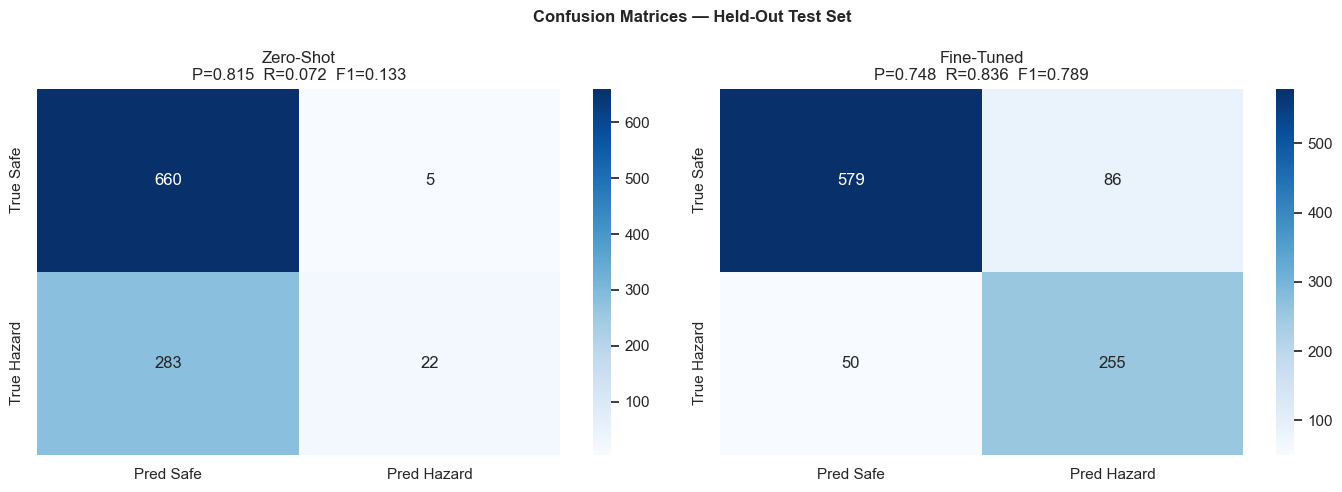

In [44]:
# ── 9.2  Confusion matrices side-by-side ─────────────────────────────
has_ft_eval = 'df_merged_ft' in dir()
ncols = 2 if has_ft_eval else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
if ncols == 1:
    axes = [axes]

for ax, df_m, tag in zip(axes,
                          [df_merged_zs] + ([df_merged_ft] if has_ft_eval else []),
                          ['Zero-Shot'] + (['Fine-Tuned'] if has_ft_eval else [])):
    cm = confusion_matrix(df_m['human_is_hazard'], df_m['pred_hazard'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Safe', 'Pred Hazard'],
                yticklabels=['True Safe', 'True Hazard'])
    tn, fp, fn, tp = cm.ravel()
    p  = round(tp / max(tp + fp, 1), 4)
    r  = round(tp / max(tp + fn, 1), 4)
    f1 = round(2 * p * r / max(p + r, 1e-9), 4)
    ax.set_title(f'{tag}\nP={p:.3f}  R={r:.3f}  F1={f1:.3f}')

fig.suptitle('Confusion Matrices — Held-Out Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

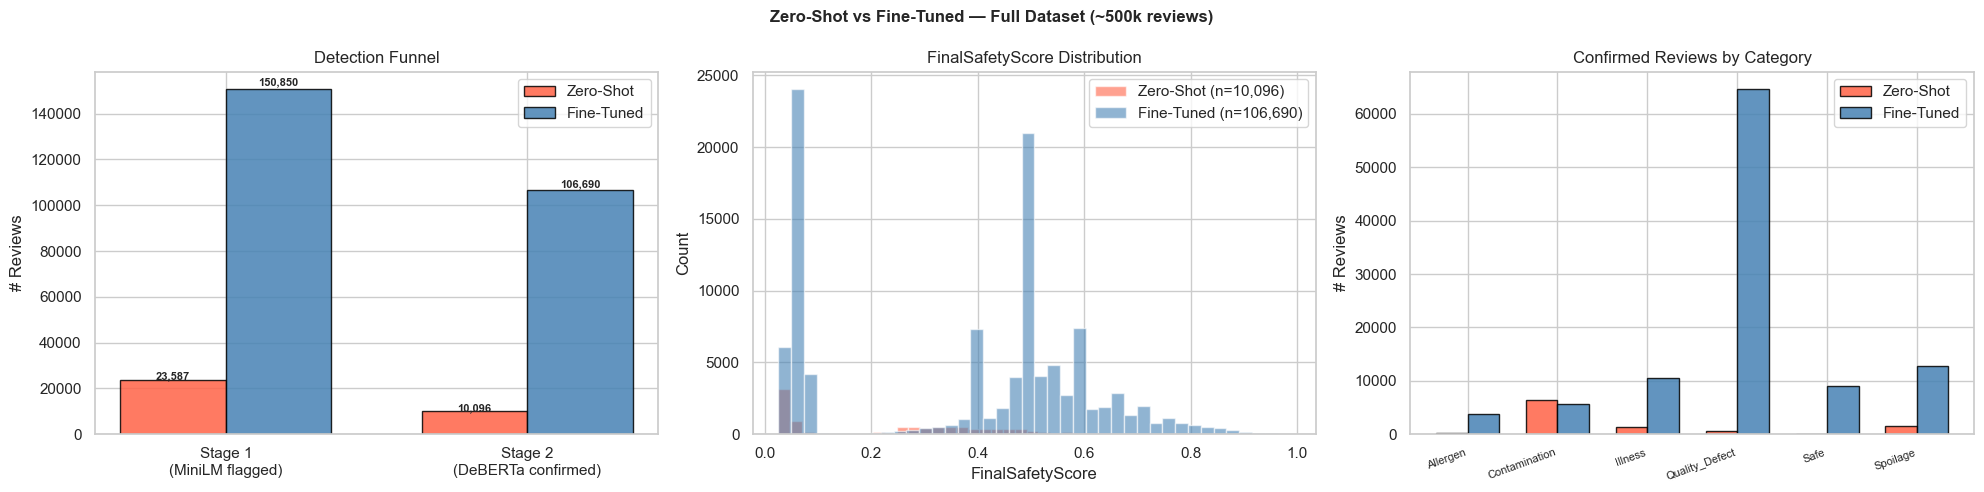

In [45]:
# ── 9.3  Pipeline funnel + 9.4 Score distributions + 9.5 Per-category ─
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Zero-Shot vs Fine-Tuned — Full Dataset (~500k reviews)',
             fontsize=12, fontweight='bold')
width = 0.35
x2    = np.arange(2)

# Panel 1: Funnel
_n_ft_flag  = n_flagged_ft  if 'n_flagged_ft'  in dir() else 0
_n_ft_conf  = n_confirmed_ft if 'n_confirmed_ft' in dir() else 0
bars_zs = axes[0].bar(x2 - width/2, [n_flagged_zs,   n_confirmed_zs],   width,
                       label='Zero-Shot',  color='tomato',    edgecolor='black', alpha=0.85)
bars_ft = axes[0].bar(x2 + width/2, [_n_ft_flag, _n_ft_conf], width,
                       label='Fine-Tuned', color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x2)
axes[0].set_xticklabels(['Stage 1\n(MiniLM flagged)', 'Stage 2\n(DeBERTa confirmed)'])
axes[0].set_title('Detection Funnel')
axes[0].set_ylabel('# Reviews')
axes[0].legend()
for bar in list(bars_zs) + list(bars_ft):
    h = int(bar.get_height())
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h*1.01,
                     f'{h:,}', ha='center', fontsize=8, fontweight='bold')

# Panel 2: Score distributions
axes[1].hist(confirmed_zs['FinalSafetyScore'], bins=40, color='tomato',    alpha=0.6,
             label=f'Zero-Shot (n={len(confirmed_zs):,})')
if 'confirmed_ft' in dir():
    axes[1].hist(confirmed_ft['FinalSafetyScore'], bins=40, color='steelblue', alpha=0.6,
                 label=f'Fine-Tuned (n={len(confirmed_ft):,})')
axes[1].set_title('FinalSafetyScore Distribution')
axes[1].set_xlabel('FinalSafetyScore')
axes[1].set_ylabel('Count')
axes[1].legend()

# Panel 3: Category breakdown comparison
cat_zs = confirmed_zs[confirmed_zs['Category'] != 'Safe']['Category'].value_counts()
if 'confirmed_ft' in dir() and 'pred_category' in confirmed_ft.columns:
    cat_ft = confirmed_ft[confirmed_ft['pred_category'] != 'safe']['pred_category'].value_counts()
    # Normalize names for side-by-side comparison
    all_cats = sorted(set(list(cat_zs.index) + [c.title().replace('_', '_') for c in cat_ft.index]))
    n_cats   = len(all_cats)
    x3       = np.arange(n_cats)
    cat_zs_vals = [cat_zs.get(c, 0) for c in all_cats]
    cat_ft_vals = [cat_ft.get(c.lower(), cat_ft.get(c, 0)) for c in all_cats]
    axes[2].bar(x3 - width/2, cat_zs_vals, width, label='Zero-Shot',  color='tomato',    edgecolor='black', alpha=0.85)
    axes[2].bar(x3 + width/2, cat_ft_vals, width, label='Fine-Tuned', color='steelblue', edgecolor='black', alpha=0.85)
    axes[2].set_xticks(x3)
    axes[2].set_xticklabels(all_cats, rotation=20, ha='right', fontsize=8)
else:
    cat_zs.plot(kind='bar', ax=axes[2], color='tomato', edgecolor='black', rot=20)
axes[2].set_title('Confirmed Reviews by Category')
axes[2].set_ylabel('# Reviews')
axes[2].legend()

plt.tight_layout()
plt.show()